# Event Detection Via Social Media Data
----

##Data Loading

In [1]:
#@title Install Packages
# Install NLTK
!pip install nltk stanza

# Import and download stopwords
import nltk
nltk.download('stopwords')

# Load Arabic stopwords
from nltk.corpus import stopwords
arabic_stopwords = stopwords.words('arabic')

# !pip install transformers
# !pip install stanza --quiet
# # !pip install --upgrade scipy

# !pip install gensim
import stanza

# Download Arabic model once
stanza.download('ar', verbose=False)

# Initialize pipeline for Arabic with NER
nlp = stanza.Pipeline('ar', processors='tokenize,ner', use_gpu=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 37.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
#@title Install Packages
!pip install transformers
# !pip install arabic-reshaper
# !pip install python-bidi
# !pip install ar_wordcloud
#@title Fix Dependency Issue
# !pip install scipy==1.10.1
# !pip uninstall -y numpy gensim
# !pip install numpy==1.24.3 gensim==4.3.1
# Fix versions to ensure compatibility
# !pip install --upgrade pip
# !pip install scipy==1.10.1
# !pip uninstall -y numpy gensim
!pip install numpy gensim tensorflow



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0;

In [1]:
# @title Install  mbert
from sentence_transformers import SentenceTransformer

# Use Arabic sentence transformer model
embedding_model = SentenceTransformer("sentence-transformers/LaBSE")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

2_Dense/pytorch_model.bin:   0%|          | 0.00/2.36M [00:00<?, ?B/s]

In [2]:
#@title import packages
import numpy as np
import requests
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from math import sqrt
# from gensim.models import KeyedVectors

# from bidi.algorithm import get_display
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sk
import matplotlib.pyplot as plt
# import arabic_reshaper
# from bidi.algorithm import get_display
from collections import Counter
import ast
# import arabic_reshaper
# from bidi.algorithm import get_display
# from ar_wordcloud import ArabicWordCloud
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

import networkx as nx


In [3]:
#@title uitlities
import re

def clean_tweet(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+', '', text)            # remove URLs
    text = re.sub(r'@\w+', '', text)                # remove mentions
    text = re.sub(r'#\w+', '', text)                # remove hashtags
    text = re.sub(r'[^ء-يa-zA-Z0-9\s]', ' ', text) # keep Arabic letters, Latin letters, numbers, and spaces only
    text = re.sub(r'\s+', ' ', text)                 # remove extra whitespace
    return text.strip()

def extract_entities_stanza(text):
    if not isinstance(text, str) or text.strip() == "":
        return []
    doc = nlp(text)
    entities = [ent.text for ent in doc.ents]
    return entities

# Function to count hashtags in a tweet
def count_hashtags(text):
    return text.count('#')


def embed_tweet(text, model):
    words = text.split()  # simple tokenization; you can replace with better Arabic tokenizer
    word_vectors = []

    for word in words:
        if word in model.key_to_index:
            word_vectors.append(model[word])
        else:
            # A zero vector if the word is OOV (out of vocab)
            word_vectors.append(np.zeros(model.vector_size))

    if word_vectors:
        # Aggregate word vectors by averaging
        tweet_vector = np.mean(word_vectors, axis=0)
    else:
        # Empty or no known words → zero vector
        tweet_vector = np.zeros(model.vector_size)

    return tweet_vector


In [4]:
# @title Utilities
# Function to embed tweet using word embeddings model
def embed_tweet(text, model):
    words = text.split()  # simple tokenization; consider replacing with a proper Arabic tokenizer
    word_vectors = []

    for word in words:
        if word in model.key_to_index:
            word_vectors.append(model[word])
        else:
            word_vectors.append(np.zeros(model.vector_size))  # out-of-vocab word

    if word_vectors:
        tweet_vector = np.mean(word_vectors, axis=0)
    else:
        tweet_vector = np.zeros(model.vector_size)

    return tweet_vector
def embed_tweet(text, model):
    """
    Embed a tweet using a SentenceTransformer model (like AraBERTv2).

    Args:
        text (str): The tweet or sentence to embed.
        model (SentenceTransformer): The sentence embedding model.

    Returns:
        np.ndarray: A vector representing the sentence.
    """
    return model.encode(text)


In [6]:
# @title Define Constants
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
#@title read the data set
df = pd.read_csv("drive/MyDrive/labeled.csv", encoding="utf-8")

In [8]:
#@title Data

df.columns

Index(['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'Label',
       'Tweet ID', 'Tweet Text', 'Type', 'Author Name', 'Author Username',
       'Creation Time', 'Reply Count', 'Retweet Count', 'Quote Count',
       'Like Count', 'View Count', 'Bookmark Count', 'Language',
       'Possibly Sensitive', 'Source', 'Hashtags', 'Tweet URL', 'Media Type',
       'Media URLs', 'External URLs', 'Old Tweet Text', 'Named Entities',
       'Persons', 'Organizations', 'Locations', 'tweet_text_replaced',
       'tweet_embedding', 'weighted_tweet_embedding'],
      dtype='object')

In [9]:
# @title Ensure Type
# Ensure datetime format
df['Creation Time'] = pd.to_datetime(df['Creation Time'])
# Convert Tweet Text to string
df["Tweet Text"] = df["Tweet Text"].astype(str)

# df.drop(columns=['Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0'], inplace=True)
# Convert stringified entity lists to actual Python lists
# entity_columns = ["Named Entities", "Person Entities", "Organization Entities", "Location Entities"]
entity_columns = ["Named Entities", "Persons", "Organizations", "Locations"]
# Convert the string embeddings into Python lists safely
def parse_embedding(s):
    # Remove brackets if exist, then convert string to numpy array
    s = s.strip('[]')
    return np.fromstring(s, sep=' ')

# Apply to your df column:
df['tweet_embedding'] = df['tweet_embedding'].apply(parse_embedding)
# for col in entity_columns:
    # df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])



In [10]:
# @title Data shape
print(df.shape)


(4565, 33)


In [11]:
#@title Clean the tweet texts
df['Old Tweet Text'] = df['Tweet Text']
df['Tweet Text'] = df['Tweet Text'].apply(clean_tweet)


In [12]:
#@title Remove Duplicates and Non-Arabic Tweets
# Remove duplicate tweets based on 'Tweet Text'
initial_count = len(df)
df = df.drop_duplicates(subset="Tweet Text", keep="first")
removed_duplicates = initial_count - len(df)
print(f"Removed {removed_duplicates} duplicate tweets. Remaining tweets: {len(df)}")

# Remove non-Arabic tweets based on 'Language' column
before_lang_filter = len(df)
df = df[df["Language"] == "ar"]
removed_non_arabic = before_lang_filter - len(df)
print(f"Removed {removed_non_arabic} non-Arabic tweets. Remaining tweets: {len(df)}")

# Drop rows with null values in 'Tweet Text' column
before_drop_na = len(df)
df = df[df["Label"].notna()]
dropped_na = before_drop_na - len(df)
print(f"Dropped {dropped_na} rows with null 'Tweet Text'. Remaining tweets: {len(df)}")


Removed 0 duplicate tweets. Remaining tweets: 4565
Removed 0 non-Arabic tweets. Remaining tweets: 4565
Dropped 0 rows with null 'Tweet Text'. Remaining tweets: 4565


# mBert Text Epreiments

## E1 Text Embedding with mBert


In [15]:
#@title Embedding the tweets

# Apply embedding to entire DataFrame column, create new column with vectors
df['tweet_embedding'] = df['Tweet Text'].apply(lambda text: embed_tweet(text, embedding_model))

# Example: check vector shape for first tweet
print(df['tweet_embedding'].iloc[0].shape)


### Sipliting the Dataset

In [14]:
X = np.vstack(df['tweet_embedding'].values)
y = df['Label'].values


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
X_train_full=X_train
X_test_full= X_test


Best Dimension: 175 with Test Accuracy: 0.8412


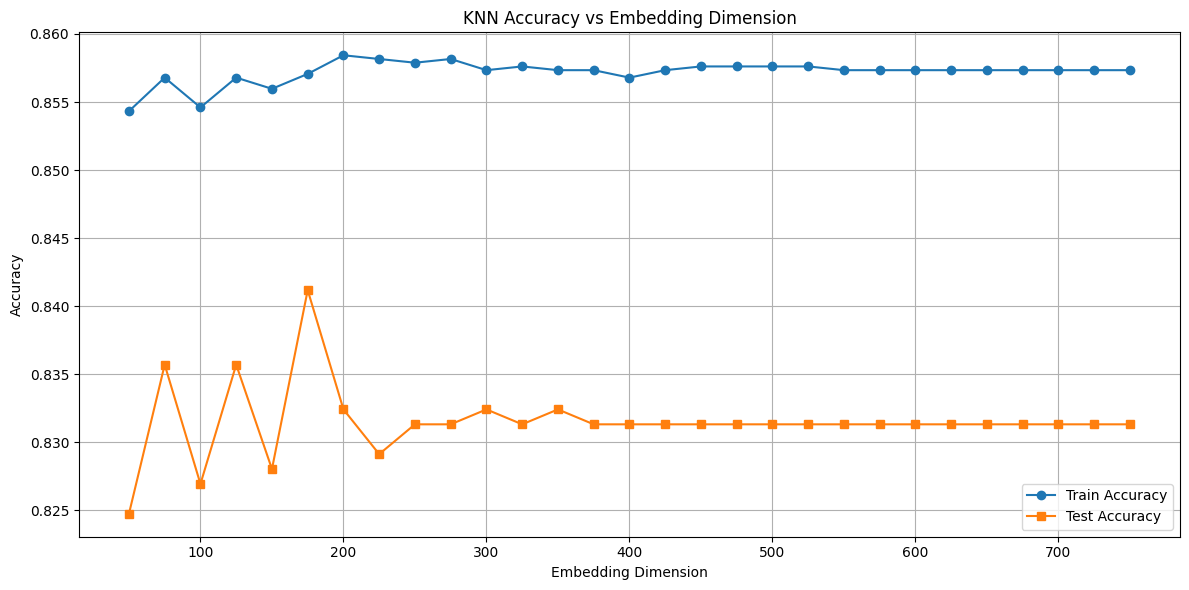

In [17]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

dims = list(range(50, 769, 25))
best_dim = 768
best_acc = 0
acc_results = []

train_accuracies = []
test_accuracies = []

for dim in dims:
    if dim < 768:
        pca = PCA(n_components=dim)
        X_train = pca.fit_transform(X_train_full)
        X_test = pca.transform(X_test_full)
    else:
        X_train = X_train_full
        X_test = X_test_full

    knn = KNeighborsClassifier(n_neighbors=15,metric='cosine')
    knn.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train))
    test_acc = accuracy_score(y_test, knn.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    acc_results.append((dim, test_acc))

    if test_acc > best_acc:
        best_acc = test_acc
        best_dim = dim

# Show best test result
print(f"\nBest Dimension: {best_dim} with Test Accuracy: {best_acc:.4f}")

# Plot both train and test accuracies
plt.figure(figsize=(12, 6))
plt.plot(dims, train_accuracies, label="Train Accuracy", marker='o')
plt.plot(dims, test_accuracies, label="Test Accuracy", marker='s')
plt.title("KNN Accuracy vs Embedding Dimension")
plt.xlabel("Embedding Dimension")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
# @title reduce the dim to 180
pca = PCA(n_components=180)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)


### K Nearest Neighbor Classifier

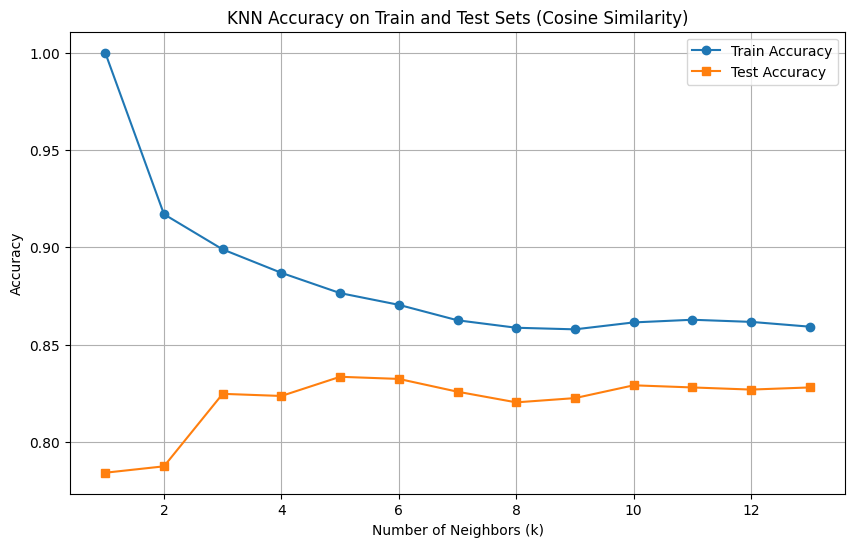

In [22]:
#@title KNN with K from 1 to root of feature size
# Number of training samples
n_train = X_train.shape[1]

# Maximum k to try: integer part of sqrt(n_train)
max_k = int(sqrt(n_train))

# Store accuracies for train and test
train_accuracies = []
test_accuracies = []

k_values = range(1, max_k + 1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict on train set and test set
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Train and Test Sets (Cosine Similarity)')
plt.legend()
plt.grid(True)
plt.show()


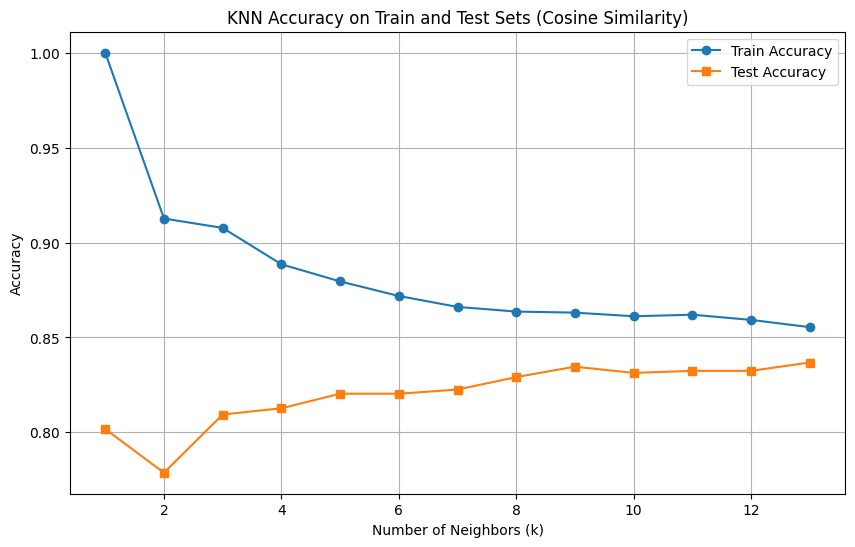

In [23]:
#@title KNN with Cosine Similarity
# Number of training samples
n_train = X_train.shape[1]

# Maximum k to try: integer part of sqrt(n_train)
max_k = int(sqrt(n_train))

# Store accuracies for train and test
train_accuracies = []
test_accuracies = []

k_values = range(1, max_k + 1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(X_train, y_train)

    # Predict on train set and test set
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Train and Test Sets (Cosine Similarity)')
plt.legend()
plt.grid(True)
plt.show()


Best k based on test accuracy: 13


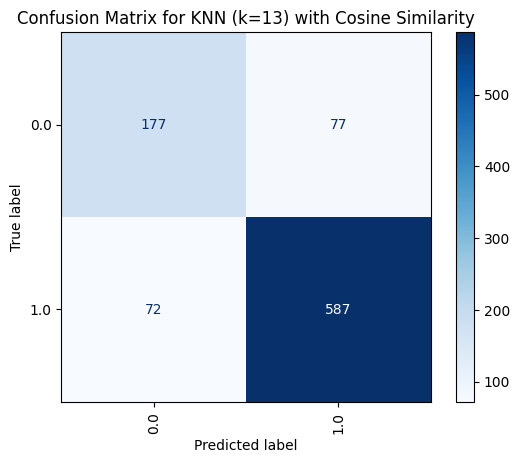

In [24]:
#@title Confuison Matrix for KNN with Cosine Similarity
# Get the best k based on test accuracy
best_k = k_values[np.argmax(test_accuracies)]
print(f"Best k based on test accuracy: {best_k}")

# Train final model with best_k
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine')
best_knn.fit(X_train, y_train)

# Predict on test set
y_test_pred = best_knn.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y_test))

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title(f'Confusion Matrix for KNN (k={best_k}) with Cosine Similarity')
plt.grid(False)
plt.show()


#### Grid Search for the best Params with accuracy Concern

In [54]:
#@title Define parameter grid
# Calculate max_k based on feature size (embedding length)
embedding_length = X_train.shape[1]
max_k = int(np.sqrt(embedding_length))

# Initialize model
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(11, max_k + 1)),
    'metric': ['cosine', 'euclidean',],
    'weights': ['uniform' ], #distance
    'algorithm': ['auto', 'brute'],
    'leaf_size': [20, 25, 30, 40],
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)


In [55]:
#@title Fit the Model
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'cosine', 'n_neighbors': 12, 'weights': 'uniform'}
Best cross-validation accuracy: 0.8055


In [56]:
#@title Classfication Report
from sklearn.metrics import classification_report

best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.78      0.78      0.78      1154
         1.0       0.90      0.90      0.90      2498

    accuracy                           0.86      3652
   macro avg       0.84      0.84      0.84      3652
weighted avg       0.86      0.86      0.86      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.69      0.73      0.71       254
         1.0       0.89      0.87      0.88       659

    accuracy                           0.83       913
   macro avg       0.79      0.80      0.80       913
weighted avg       0.84      0.83      0.83       913



<Figure size 600x500 with 0 Axes>

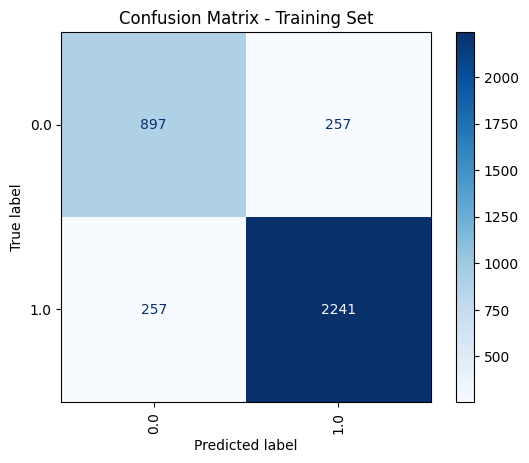

<Figure size 600x500 with 0 Axes>

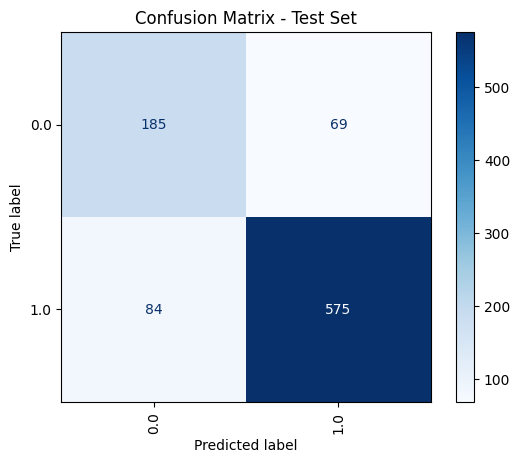

In [57]:
#@title Confusion Matrix
# Define labels to ensure consistent order in the matrix
labels = np.unique(y_test)

# Confusion Matrix for Training Set
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
plt.figure(figsize=(6,5))
disp_train.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Training Set')
plt.grid(False)
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
plt.figure(figsize=(6,5))
disp_test.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.grid(False)
plt.show()

#### Grid Search for the best Params with recall Concern

In [59]:
#@title Define parameter grid
# Calculate max_k based on feature size (embedding length)
embedding_length = X_train.shape[1]
max_k = int(np.sqrt(embedding_length))

# Initialize model
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(13, max_k + 1)),
    'metric': ['cosine', 'euclidean',],
    'weights': ['uniform'], #distance
    'algorithm': ['auto', 'brute'],
    'leaf_size': [20, 25, 30, 40],
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)


In [60]:
#@title Fit the Model
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'cosine', 'n_neighbors': 13, 'weights': 'uniform'}
Best cross-validation accuracy: 0.7952


In [61]:
#@title Classfication Report
from sklearn.metrics import classification_report

best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.79      0.74      0.76      1154
         1.0       0.88      0.91      0.90      2498

    accuracy                           0.86      3652
   macro avg       0.84      0.82      0.83      3652
weighted avg       0.85      0.86      0.85      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.71      0.70      0.70       254
         1.0       0.88      0.89      0.89       659

    accuracy                           0.84       913
   macro avg       0.80      0.79      0.80       913
weighted avg       0.84      0.84      0.84       913



<Figure size 600x500 with 0 Axes>

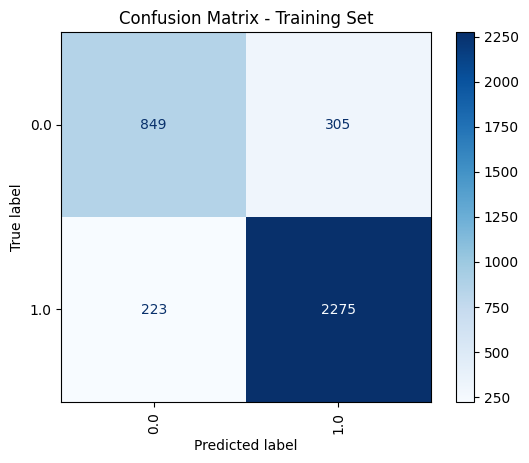

<Figure size 600x500 with 0 Axes>

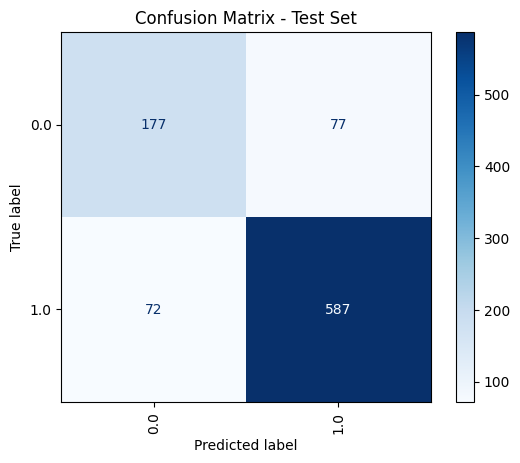

In [62]:
#@title Confusion Matrix
# Define labels to ensure consistent order in the matrix
labels = np.unique(y_test)

# Confusion Matrix for Training Set
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
plt.figure(figsize=(6,5))
disp_train.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Training Set')
plt.grid(False)
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
plt.figure(figsize=(6,5))
disp_test.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.grid(False)
plt.show()

### SVM

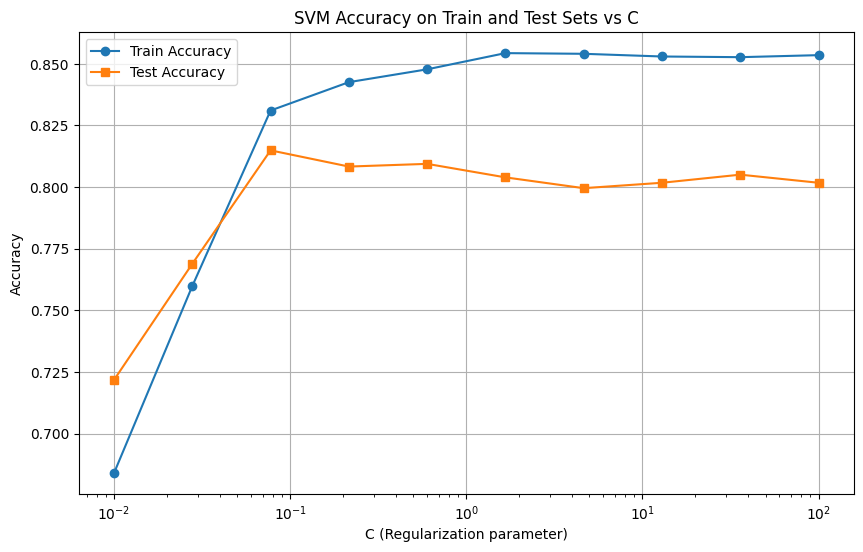

In [37]:
#@title SVM with Linear kernel (jsut to show a base line )
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Define a range of C values to try (log scale)
C_values = np.logspace(-2, 2, 10)  # 0.01 to 100

train_accuracies = []
test_accuracies = []

for C in C_values:
    svm = SVC(C=C, kernel='linear')  # using linear kernel, you can try others like 'rbf'
    svm.fit(X_train, y_train)

    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(C_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xscale('log')
plt.xlabel('C (Regularization parameter)')
plt.ylabel('Accuracy')
plt.title('SVM Accuracy on Train and Test Sets vs C')
plt.legend()
plt.grid(True)
plt.show()


#### Grid Search  with f1 concern

In [63]:
#@title Define Parameter Grid
from sklearn.svm import SVC

svm = SVC()

param_grid = {
    'C': [0.01,0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'poly'],  # Kernel types to try'rbf'

    'gamma': ['scale', 'auto'],  # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
    'degree': [2, 3, 4] # Degree for the 'poly' kernel
}

grid_search_svm = GridSearchCV(svm, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)

In [64]:
#@title Fit the Model
grid_search_svm.fit(X_train, y_train)

print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_svm.best_score_:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.7964


In [65]:

#@title Classification Report
from sklearn.metrics import classification_report

best_svm = grid_search_svm.best_estimator_

y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.78      0.75      0.76      1154
         1.0       0.89      0.90      0.89      2498

    accuracy                           0.85      3652
   macro avg       0.83      0.83      0.83      3652
weighted avg       0.85      0.85      0.85      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.67      0.65      0.66       254
         1.0       0.87      0.88      0.87       659

    accuracy                           0.81       913
   macro avg       0.77      0.77      0.77       913
weighted avg       0.81      0.81      0.81       913



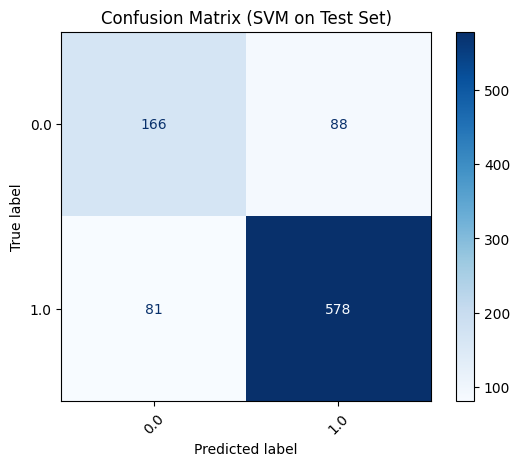

In [66]:
#@title Confusion Matrix
# Predict using the best model from GridSearch
y_pred = grid_search_svm.best_estimator_.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_svm.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (SVM on Test Set)")
plt.grid(False)
plt.show()


In [67]:
import joblib

# @title  Save the grid search SVM model to a file
joblib.dump(grid_search_svm, 'grid_search_svm_model.joblib')
print("SVM Grid Search model saved as 'grid_search_svm_model.joblib'")


SVM Grid Search model saved as 'grid_search_svm_model.joblib'


#### Grid Search  with Recall concern

In [88]:
#@title Define Parameter Grid
from sklearn.svm import SVC

svm = SVC()

param_grid = {
    'C': [ 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', ],  # Kernel types to try'rbf' poly
    # 'gamma': ['scale', 'auto'],  # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
    # 'degree': [2, 3, 4] # Degree for the 'poly' kernel
}

grid_search_svm = GridSearchCV(svm, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=2)

In [89]:
#@title Fit the Model
grid_search_svm.fit(X_train, y_train)

print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_svm.best_score_:.4f}")


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best parameters: {'C': 1, 'kernel': 'linear'}
Best cross-validation accuracy: 0.8827


In [90]:

#@title Classification Report
best_svm = grid_search_svm.best_estimator_

y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.78      0.75      0.76      1154
         1.0       0.89      0.90      0.89      2498

    accuracy                           0.85      3652
   macro avg       0.83      0.83      0.83      3652
weighted avg       0.85      0.85      0.85      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.67      0.65      0.66       254
         1.0       0.87      0.88      0.87       659

    accuracy                           0.81       913
   macro avg       0.77      0.77      0.77       913
weighted avg       0.81      0.81      0.81       913



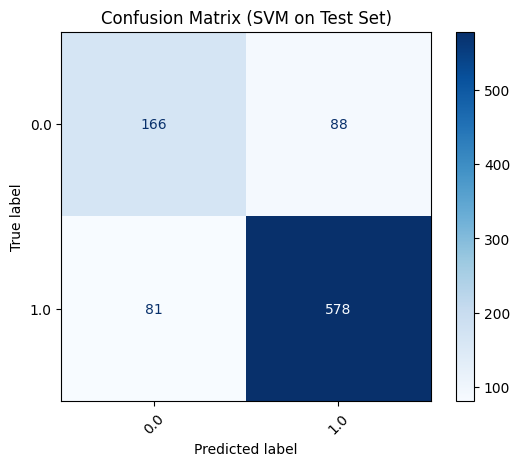

In [91]:
#@title Confusion Matrix
# Predict using the best model from GridSearch
y_pred = grid_search_svm.best_estimator_.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_svm.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (SVM on Test Set)")
plt.grid(False)
plt.show()


In [92]:
# import joblib

# @title  Save the grid search SVM model to a file
joblib.dump(grid_search_svm, 'grid_search_svm_model.joblib')
print("SVM Grid Search model saved as 'grid_search_svm_model.joblib'")


SVM Grid Search model saved as 'grid_search_svm_model.joblib'


### Logistic Regression

In [93]:
#@title Logistic Regression with Default Parameters
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Train Accuracy: 0.8406
Test Accuracy: 0.8138


In [94]:
#@title Logistic Regression with Grid Search
from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l2'],                   # L2 is commonly used
    'solver': ['liblinear', 'lbfgs'],    # liblinear for small data, lbfgs is default
}

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.8234


In [95]:
#@title Classification Report for Logistic Regression
from sklearn.metrics import classification_report

best_logreg = grid_search.best_estimator_

y_train_pred = best_logreg.predict(X_train)
y_test_pred = best_logreg.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.77      0.70      0.74      1154
         1.0       0.87      0.90      0.89      2498

    accuracy                           0.84      3652
   macro avg       0.82      0.80      0.81      3652
weighted avg       0.84      0.84      0.84      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.68      0.63      0.65       254
         1.0       0.86      0.88      0.87       659

    accuracy                           0.81       913
   macro avg       0.77      0.76      0.76       913
weighted avg       0.81      0.81      0.81       913



<Figure size 600x600 with 0 Axes>

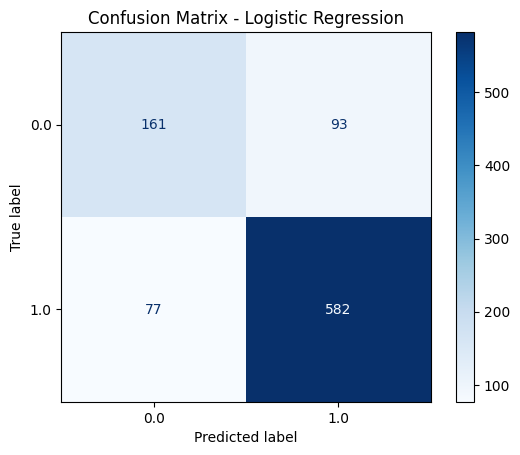

In [96]:
#@title Confusion Matrix for Logistic Regression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test set
y_test_pred = best_logreg.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=best_logreg.classes_)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_logreg.classes_)
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Naive Baise

In [97]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize Gaussian Naive Bayes
gnb = GaussianNB()

# Fit the model
gnb.fit(X_train, y_train)

# Predict on train and test
y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)

# Print accuracies
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


Train Accuracy: 0.7376779846659365
Test Accuracy: 0.7097480832420592


In [98]:
print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.57      0.66      0.61      1154
         1.0       0.83      0.78      0.80      2498

    accuracy                           0.74      3652
   macro avg       0.70      0.72      0.71      3652
weighted avg       0.75      0.74      0.74      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.49      0.74      0.59       254
         1.0       0.87      0.70      0.78       659

    accuracy                           0.71       913
   macro avg       0.68      0.72      0.68       913
weighted avg       0.77      0.71      0.72       913



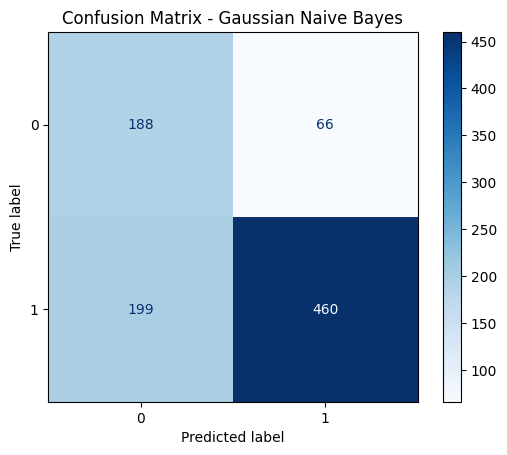

In [99]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()


### Neural Network

In [100]:
# pip install --upgrade --force-reinstall numpy tensorflow


In [126]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

layers = [
    Dense(units=64, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.4),

    # Dense(units=64, activation='relu', kernel_regularizer=l2(0.01)),
    # BatchNormalization(),
    # Dropout(rate=0.25),

    Dense(units=32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.3),

    Dense(units=8, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(rate=0.1),

    Dense(units=2, activation='softmax')  # Adjust units if your number of classes differs
]

model = Sequential(layers)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # Use 'categorical_crossentropy' if y_train is one-hot encoded
    metrics=['accuracy']
)


In [127]:

#@title  Fit the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64
)


Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5488 - loss: 2.4393 - val_accuracy: 0.7218 - val_loss: 1.9662
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6549 - loss: 1.9832 - val_accuracy: 0.7218 - val_loss: 1.8056
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7080 - loss: 1.7582 - val_accuracy: 0.7218 - val_loss: 1.6547
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7489 - loss: 1.5853 - val_accuracy: 0.7218 - val_loss: 1.5089
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7520 - loss: 1.4584 - val_accuracy: 0.7503 - val_loss: 1.3767
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7974 - loss: 1.2934 - val_accuracy: 0.8127 - val_loss: 1.2494
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7991 - loss: 1.1785 - val_accuracy: 0.8094 - val_loss: 1.1341
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8175 - loss: 1.0803 - val_accuracy: 0.8127 - val_loss

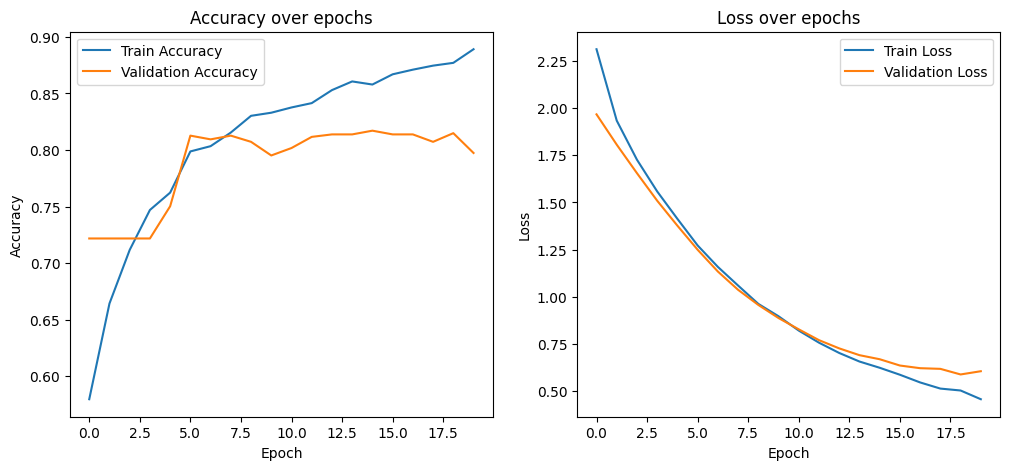

In [128]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



In [129]:

from sklearn.metrics import classification_report

# Predict on training set
y_train_pred_prob = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred_prob, axis=1)

# Predict on test (validation) set
y_test_pred_prob = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Validation Set")
print(classification_report(y_test, y_test_pred))


115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.89      1154
         1.0       0.97      0.93      0.95      2498

    accuracy                           0.93      3652
   macro avg       0.91      0.93      0.92      3652
weighted avg       0.93      0.93      0.93      3652

Classification Report - Validation Set
              precision    recall  f1-score   support

         0.0       0.61      0.74      0.67       254
         1.0       0.89      0.82      0.85       659

    accuracy                           0.80       913
   macro avg       0.75      0.78      0.76       913
weighted avg       0.81      0.80      0.80       913



<Figure size 600x600 with 0 Axes>

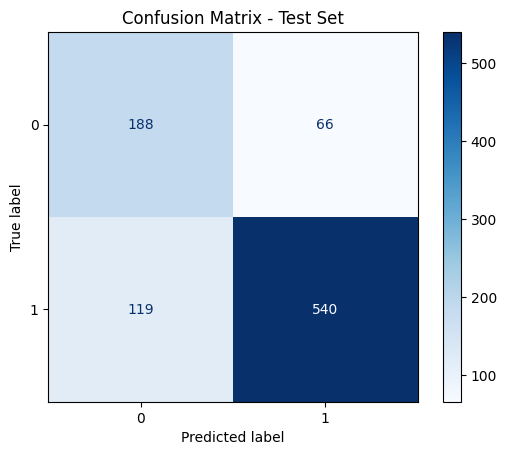

In [130]:
# Predict classes on test set
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.show()


### BiLSTM

In [131]:
import random

def random_drop_tokens(text, drop_prob=0.2):
    words = text.split()
    if len(words) <= 1:
        return text  # skip too short
    kept = [w for w in words if random.random() > drop_prob]
    return " ".join(kept) if kept else text


In [132]:
def shuffle_middle_tokens(text):
    words = text.split()
    if len(words) <= 3:
        return text
    middle = words[1:-1]
    random.shuffle(middle)
    return " ".join([words[0]] + middle + [words[-1]])


In [133]:
!pip install nlpaug


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 6.6 MB/s eta 0:00:00


In [134]:
import nlpaug.augmenter.word as naw

# Use contextual word embeddings (e.g., mBERT or AraBERT)
aug = naw.ContextualWordEmbsAug(
    model_path='aubmindlab/bert-base-arabertv2',
    action="substitute", top_k=5
)

# Apply to a tweet
augmented_text = aug.augment("الرئيس أحمد الشرع اعتمد اثنين مليون دولار كدعم استثنائي للمحافظة لترميم الطرق وإصلاح الخدمات العامة فيها.")
print(augmented_text)


tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

The following layers were not sharded: bert.encoder.layer.*.intermediate.dense.bias, bert.embeddings.LayerNorm.bias, bert.encoder.layer.*.attention.output.dense.weight, bert.encoder.layer.*.attention.self.key.weight, bert.encoder.layer.*.attention.output.LayerNorm.weight, cls.predictions.decoder.weight, cls.predictions.decoder.bias, bert.encoder.layer.*.intermediate.dense.weight, bert.encoder.layer.*.attention.self.query.weight, bert.encoder.layer.*.attention.self.value.bias, bert.encoder.layer.*.attention.output.dense.bias, cls.predictions.transform.dense.bias, bert.encoder.layer.*.attention.self.value.weight, bert.embeddings.LayerNorm.weight, bert.embeddings.position_embeddings.weight, bert.encoder.layer.*.output.dense.weight, cls.predictions.bias, cls.predictions.transform.LayerNorm.weight, bert.embeddings.token_type_embeddings.weight, cls.predictions.transform.LayerNorm.bias, cls.predictions.transform.dense.weight, bert.encoder.layer.*.attention.self.key.bias, bert.encoder.layer.*.

['ثاني +ا الشرع +ه 2 بليون دولار مساعد +ين للمحافظة لترميم إصلاح وإصلاح الخدمات العامة +ة.']


In [135]:
def augment_tweet(text):
    funcs = [
        lambda x: x,  # keep as is
        random_drop_tokens,
        shuffle_middle_tokens
    ]
    func = random.choice(funcs)
    return func(text)


In [136]:
from sklearn.model_selection import train_test_split

# Assume: df has 'Tweet Text' and 'Label'
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])


In [137]:
# Make a copy and augment it
df_aug = df_train.copy()
df_aug['Tweet Text'] = df_aug['Tweet Text'].apply(augment_tweet)

# Combine original + augmented training data
df_train_augmented = pd.concat([df_train, df_aug], ignore_index=True)


In [ ]:

from sentence_transformers import SentenceTransformer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from tqdm import tqdm

embedding_model = SentenceTransformer("aubmindlab/bert-base-arabertv2")

MAX_LEN = 32
EMBED_DIM = embedding_model.get_sentence_embedding_dimension()

def fast_token_embeddings(text):
    # Simple whitespace tokenizer, truncate to MAX_LEN tokens
    tokens = text.strip().split()[:MAX_LEN]
    if not tokens:
        return [np.zeros(EMBED_DIM)]
    # Encode tokens all at once (faster)
    token_vecs = embedding_model.encode(tokens, show_progress_bar=False)
    return token_vecs

# For training augmented set:
sequence_embeddings_train = []
for text in tqdm(df_train_augmented['Tweet Text']):
    token_vecs = fast_token_embeddings(text)
    sequence_embeddings_train.append(token_vecs)

padded_train = pad_sequences(
    sequence_embeddings_train,
    maxlen=MAX_LEN,
    dtype='float32',
    padding='post',
    truncating='post',
    value=np.zeros(EMBED_DIM)
)

X_train = np.array(padded_train)
y_train = df_train_augmented['Label'].values

# For test set:
sequence_embeddings_test = []
for text in tqdm(df_test['Tweet Text']):
    token_vecs = fast_token_embeddings(text)
    sequence_embeddings_test.append(token_vecs)

padded_test = pad_sequences(
    sequence_embeddings_test,
    maxlen=MAX_LEN,
    dtype='float32',
    padding='post',
    truncating='post',
    value=np.zeros(EMBED_DIM)
)

X_test = np.array(padded_test)
y_test = df_test['Label'].values

# Now X_train and X_test have shape: (samples, MAX_LEN, EMBED_DIM)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")



The following layers were not sharded: encoder.layer.*.attention.output.LayerNorm.weight, pooler.dense.weight, embeddings.word_embeddings.weight, encoder.layer.*.attention.self.key.bias, encoder.layer.*.intermediate.dense.bias, embeddings.LayerNorm.weight, encoder.layer.*.output.LayerNorm.weight, encoder.layer.*.attention.output.dense.bias, encoder.layer.*.attention.self.query.bias, encoder.layer.*.output.dense.weight, encoder.layer.*.intermediate.dense.weight, embeddings.token_type_embeddings.weight, encoder.layer.*.attention.self.query.weight, encoder.layer.*.attention.output.dense.weight, encoder.layer.*.attention.self.value.weight, encoder.layer.*.output.LayerNorm.bias, encoder.layer.*.attention.self.value.bias, encoder.layer.*.output.dense.bias, embeddings.LayerNorm.bias, encoder.layer.*.attention.output.LayerNorm.bias, encoder.layer.*.attention.self.key.weight, pooler.dense.bias, embeddings.position_embeddings.weight
 15%|█▍        | 1085/7304 [13:27<56:23,  1.84it/s]  

In [ ]:

# Reshape for LSTM
X = np.vstack(df['tweet_embedding'].values)
X = X.reshape((X.shape[0], 1, X.shape[1]))  # (samples, timesteps=1, features)

y = df['Label'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,      # stop if val_loss doesn't improve for 3 epochs
    restore_best_weights=True
)

# Model
model = Sequential([
    Input(shape=(MAX_LEN, EMBED_DIM)),
    Bidirectional(LSTM(64, return_sequences=False, dropout=0.6, recurrent_dropout=0.2)),
    Dense(32, activation='relu'),
    Dropout(0.6),
    Dense(2, activation='softmax')
])


# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,  # increased, since we'll stop early
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



In [ ]:

from sklearn.metrics import classification_report

# Predict on training set
y_train_pred_prob = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred_prob, axis=1)

# Predict on test (validation) set
y_test_pred_prob = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Validation Set")
print(classification_report(y_test, y_test_pred))


In [ ]:
# Predict classes on test set
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.show()


## E2 Taking a wieght for the Named Entities

In [ ]:
#@title Weighting the embeding by the named entites
# ✅ Load LaBSE model & tokenizer
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

model_name = "sentence-transformers/LaBSE"
tokenizer = AutoTokenizer.from_pretrained(model_name)
labse_model = AutoModel.from_pretrained(model_name)
labse_model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
labse_model.to(device)

# Function to get [CLS] embedding (sentence-level)
def get_labse_embedding(text, tokenizer, model, device):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()  # [CLS]
# Final function: tweet + named entity weighted average
def embed_tweet_with_named_entities(text, named_entities, tokenizer, model, ner_weight=2.0, device='cpu'):
    tweet_emb = get_labse_embedding(text, tokenizer, model, device)

    # If named_entities is a stringified list, convert
    if isinstance(named_entities, str):
        try:
            named_entities = ast.literal_eval(named_entities)
        except:
            named_entities = []

    # Join named entities into one string and embed
    if named_entities:
        ner_text = " ".join(named_entities)
        ner_emb = get_labse_embedding(ner_text, tokenizer, model, device)
    else:
        ner_emb = np.zeros_like(tweet_emb)

    # Weighted average
    combined_emb = (tweet_emb + ner_weight * ner_emb) / (1 + ner_weight)
    return combined_emb
# Apply to all tweets
from tqdm import tqdm
tqdm.pandas(desc="Embedding tweets with NER weight")

df['weighted_tweet_embedding'] = df.progress_apply(
    lambda row: embed_tweet_with_named_entities(
        row['Tweet Text'], row['Named Entities'], tokenizer, labse_model, ner_weight=2.0, device=device
    ),
    axis=1
)


Embedding tweets with NER weight:  93%|█████████▎| 4258/4565 [17:19<01:31,  3.36it/s]

In [14]:
#@title Split the DF
X = np.vstack(df['weighted_tweet_embedding'].values)
y = df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
X_train_full=X_train
X_test_full= X_test


Best Dimension: 275 with Test Accuracy: 0.7788


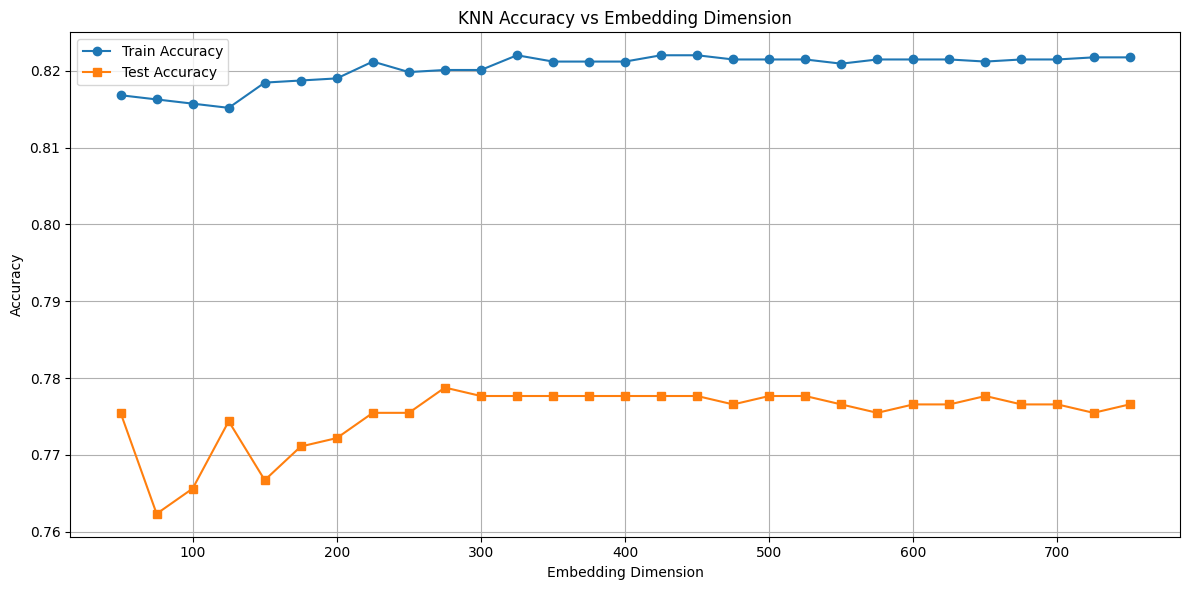

In [16]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

dims = list(range(50, 769, 25))
best_dim = 768
best_acc = 0
acc_results = []

train_accuracies = []
test_accuracies = []

for dim in dims:
    if dim < 768:
        pca = PCA(n_components=dim)
        X_train = pca.fit_transform(X_train_full)
        X_test = pca.transform(X_test_full)
    else:
        X_train = X_train_full
        X_test = X_test_full

    knn = KNeighborsClassifier(n_neighbors=15,metric='cosine')
    knn.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train))
    test_acc = accuracy_score(y_test, knn.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    acc_results.append((dim, test_acc))

    if test_acc > best_acc:
        best_acc = test_acc
        best_dim = dim

# Show best test result
print(f"\nBest Dimension: {best_dim} with Test Accuracy: {best_acc:.4f}")

# Plot both train and test accuracies
plt.figure(figsize=(12, 6))
plt.plot(dims, train_accuracies, label="Train Accuracy", marker='o')
plt.plot(dims, test_accuracies, label="Test Accuracy", marker='s')
plt.title("KNN Accuracy vs Embedding Dimension")
plt.xlabel("Embedding Dimension")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
# @title reduce the dim to 200
pca = PCA(n_components=200)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)


### K Nearest Neighbor Classifier

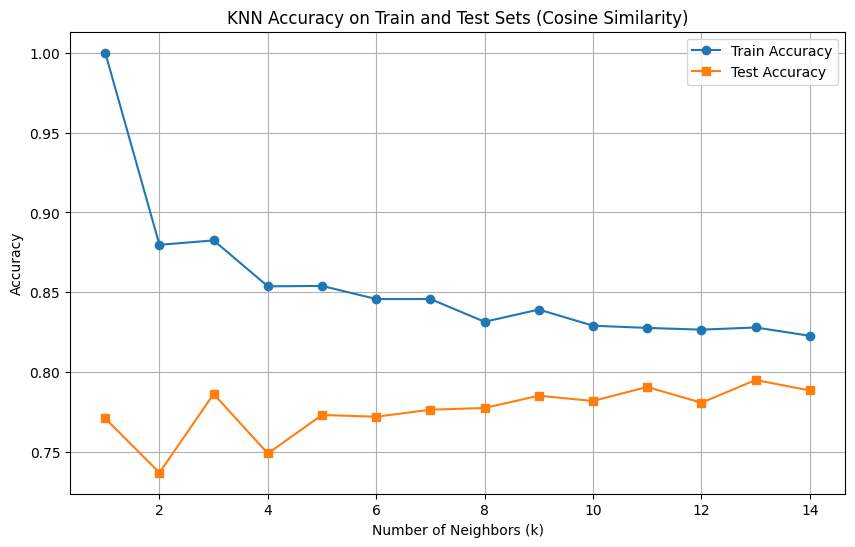

In [24]:
#@title KNN with K from 1 to root of feature size
# Number of training samples
n_train = X_train.shape[1]

# Maximum k to try: integer part of sqrt(n_train)
max_k = int(sqrt(n_train))

# Store accuracies for train and test
train_accuracies = []
test_accuracies = []

k_values = range(1, max_k + 1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict on train set and test set
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Train and Test Sets (Cosine Similarity)')
plt.legend()
plt.grid(True)
plt.show()


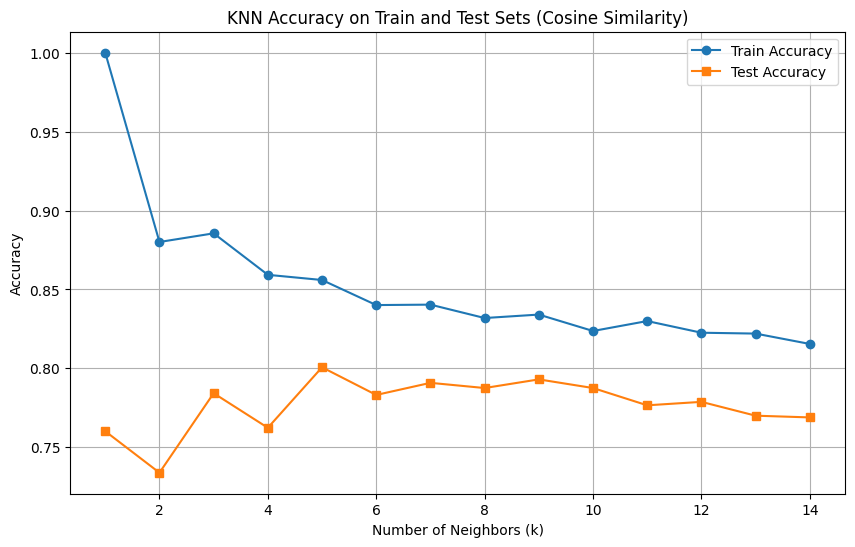

In [25]:
#@title KNN with Cosine Similarity
# Number of training samples
n_train = X_train.shape[1]

# Maximum k to try: integer part of sqrt(n_train)
max_k = int(sqrt(n_train))

# Store accuracies for train and test
train_accuracies = []
test_accuracies = []

k_values = range(1, max_k + 1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(X_train, y_train)

    # Predict on train set and test set
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Train and Test Sets (Cosine Similarity)')
plt.legend()
plt.grid(True)
plt.show()


Best k based on test accuracy: 5


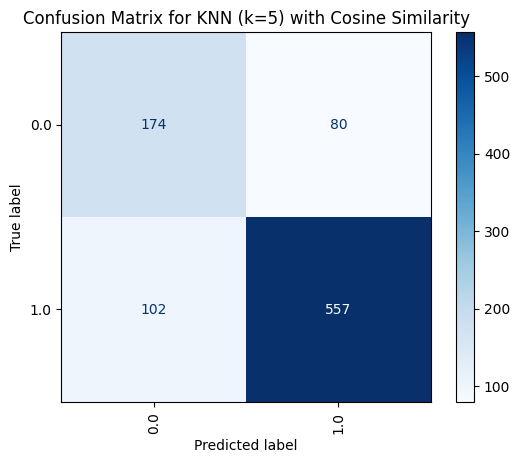

In [26]:
#@title Confuison Matrix for KNN with Cosine Similarity
# Get the best k based on test accuracy
best_k = k_values[np.argmax(test_accuracies)]
print(f"Best k based on test accuracy: {best_k}")

# Train final model with best_k
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine')
best_knn.fit(X_train, y_train)

# Predict on test set
y_test_pred = best_knn.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y_test))

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title(f'Confusion Matrix for KNN (k={best_k}) with Cosine Similarity')
plt.grid(False)
plt.show()


#### Grid Search for the best Params with accuracy Concern

In [27]:
#@title Define parameter grid
# Calculate max_k based on feature size (embedding length)
embedding_length = X_train.shape[1]
max_k = int(np.sqrt(embedding_length))

# Initialize model
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(7, max_k + 1)),
    'metric': ['cosine', 'euclidean',],
    'weights': ['uniform'], # , 'distance'
    'algorithm': ['auto'],
    'leaf_size': [25, 30, 35, 40],
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)


In [28]:
#@title Fit the Model
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'algorithm': 'auto', 'leaf_size': 25, 'metric': 'cosine', 'n_neighbors': 8, 'weights': 'uniform'}
Best cross-validation accuracy: 0.7494


In [29]:
#@title Classfication Report
from sklearn.metrics import classification_report

best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.72      0.77      0.74      1154
         1.0       0.89      0.86      0.88      2498

    accuracy                           0.83      3652
   macro avg       0.80      0.81      0.81      3652
weighted avg       0.84      0.83      0.83      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.60      0.70      0.65       254
         1.0       0.88      0.82      0.85       659

    accuracy                           0.79       913
   macro avg       0.74      0.76      0.75       913
weighted avg       0.80      0.79      0.79       913



<Figure size 600x500 with 0 Axes>

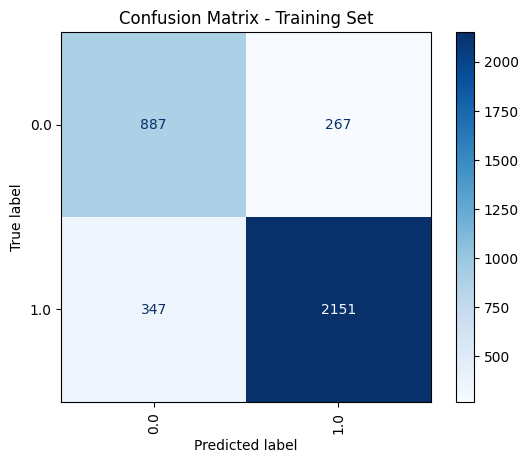

<Figure size 600x500 with 0 Axes>

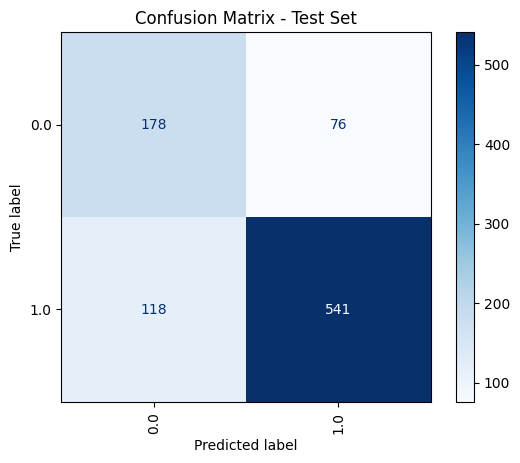

In [30]:
#@title Confusion Matrix
# Define labels to ensure consistent order in the matrix
labels = np.unique(y_test)

# Confusion Matrix for Training Set
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
plt.figure(figsize=(6,5))
disp_train.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Training Set')
plt.grid(False)
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
plt.figure(figsize=(6,5))
disp_test.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.grid(False)
plt.show()

#### Grid Search for the best Params with recall Concern

In [43]:
#@title Define parameter grid
# Calculate max_k based on feature size (embedding length)
embedding_length = X_train.shape[1]
max_k = int(np.sqrt(embedding_length))

# Initialize model
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(7, max_k + 1)),
    'metric': ['cosine', 'euclidean',],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'brute'],
    'leaf_size': [20, 25, 30, 40],
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)


In [44]:
#@title Fit the Model
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Best parameters: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'cosine', 'n_neighbors': 8, 'weights': 'uniform'}
Best cross-validation accuracy: 0.7571


In [45]:
#@title Classfication Report
from sklearn.metrics import classification_report

best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.72      0.77      0.74      1154
         1.0       0.89      0.86      0.88      2498

    accuracy                           0.83      3652
   macro avg       0.80      0.81      0.81      3652
weighted avg       0.84      0.83      0.83      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.60      0.70      0.65       254
         1.0       0.88      0.82      0.85       659

    accuracy                           0.79       913
   macro avg       0.74      0.76      0.75       913
weighted avg       0.80      0.79      0.79       913



<Figure size 600x500 with 0 Axes>

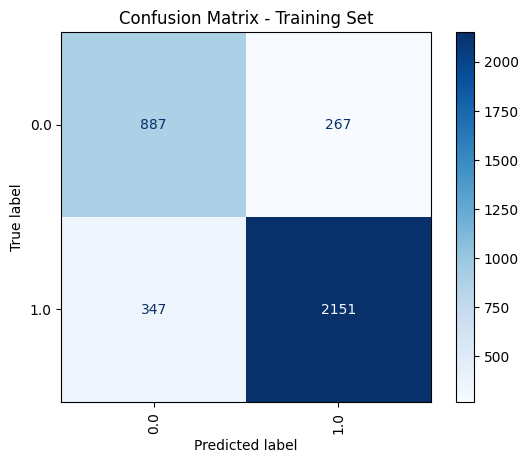

<Figure size 600x500 with 0 Axes>

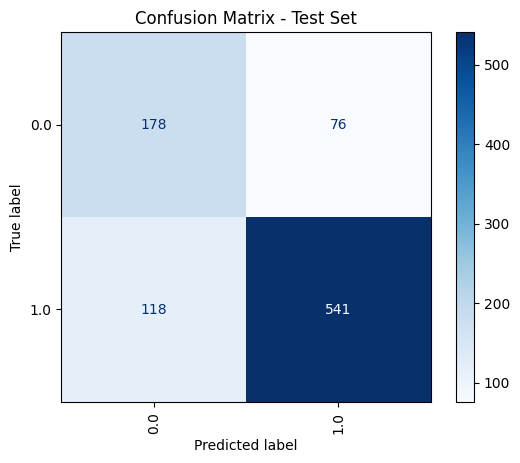

In [46]:
#@title Confusion Matrix
# Define labels to ensure consistent order in the matrix
labels = np.unique(y_test)

# Confusion Matrix for Training Set
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
plt.figure(figsize=(6,5))
disp_train.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Training Set')
plt.grid(False)
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
plt.figure(figsize=(6,5))
disp_test.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.grid(False)
plt.show()

### SVM

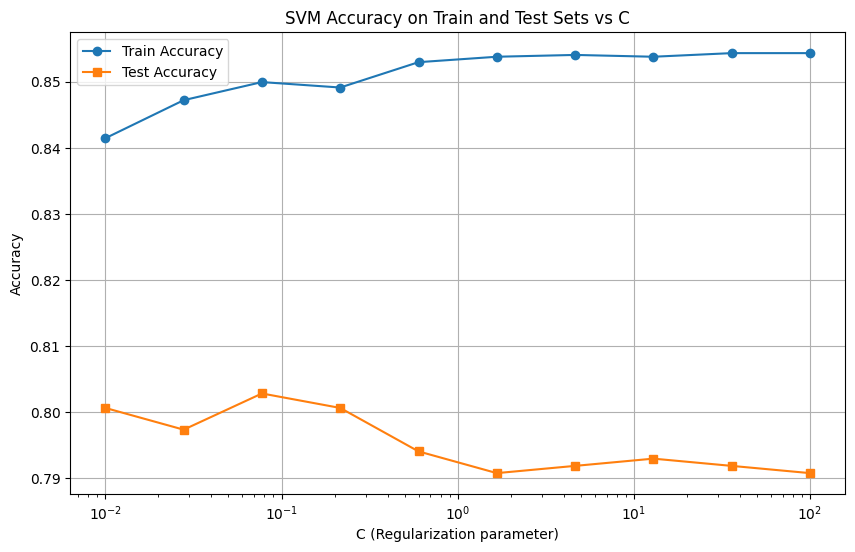

In [47]:
#@title SVM with Linear kernel
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Define a range of C values to try (log scale)
C_values = np.logspace(-2, 2, 10)  # 0.01 to 100

train_accuracies = []
test_accuracies = []

for C in C_values:
    svm = SVC(C=C, kernel='linear')  # using linear kernel, you can try others like 'rbf'
    svm.fit(X_train, y_train)

    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(C_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xscale('log')
plt.xlabel('C (Regularization parameter)')
plt.ylabel('Accuracy')
plt.title('SVM Accuracy on Train and Test Sets vs C')
plt.legend()
plt.grid(True)
plt.show()


#### Grid Search  with f1 concern

In [18]:
#@title Define Parameter Grid
from sklearn.svm import SVC

svm = SVC()

param_grid = {
    'C': [0.001,0.01,0.1, 1],  # Regularization parameter
    'kernel': ['linear', 'poly'],  # Kernel types to try'rbf'
    'gamma': ['scale', 'auto'],  # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
    'degree': [2, 3, 4] # Degree for the 'poly' kernel
}

grid_search_svm = GridSearchCV(svm, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [19]:
#@title Fit the Model
grid_search_svm.fit(X_train, y_train)

print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_svm.best_score_:.4f}")


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'C': 0.01, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.7851


In [21]:
#@title Classification Report
from sklearn.metrics import classification_report

best_svm = grid_search_svm.best_estimator_

y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))

Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74      1154
         1.0       0.87      0.90      0.89      2498

    accuracy                           0.84      3652
   macro avg       0.82      0.81      0.81      3652
weighted avg       0.84      0.84      0.84      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.65      0.64      0.64       254
         1.0       0.86      0.86      0.86       659

    accuracy                           0.80       913
   macro avg       0.75      0.75      0.75       913
weighted avg       0.80      0.80      0.80       913



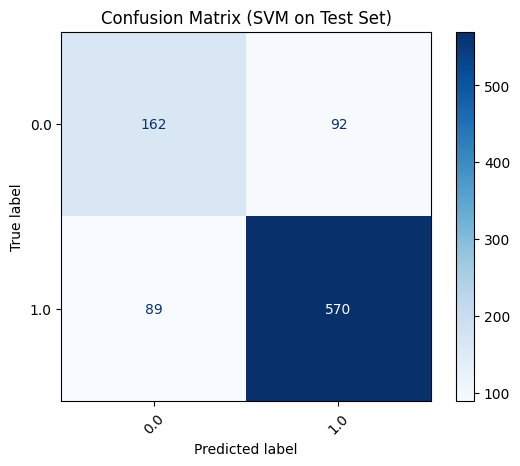

In [22]:
#@title Confusion Matrix
# Predict using the best model from GridSearch
y_pred = grid_search_svm.best_estimator_.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_svm.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (SVM on Test Set)")
plt.grid(False)
plt.show()


In [23]:
# import joblib

# @title  Save the grid search SVM model to a file
# joblib.dump(grid_search_svm, 'grid_search_svm_model.joblib')
print("SVM Grid Search model saved as 'grid_search_svm_model.joblib'")


SVM Grid Search model saved as 'grid_search_svm_model.joblib'


#### Grid Search  with Recall concern

In [29]:
#@title Define Parameter Grid
from sklearn.svm import SVC

svm = SVC()

param_grid = {
    'C': [0.01,0.1, 1, 10],  # Regularization parameter
    'kernel': ['linear', ],  # Kernel types to try'rbf'poly
    'gamma': ['scale', 'auto'],  # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
    'degree': [2, 3, 4] # Degree for the 'poly' kernel
}

grid_search_svm = GridSearchCV(svm, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=2)

In [30]:
#@title Fit the Model
grid_search_svm.fit(X_train, y_train)

print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_svm.best_score_:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'C': 0.01, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.8883


In [31]:

#@title Classification Report
best_svm = grid_search_svm.best_estimator_

y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74      1154
         1.0       0.87      0.90      0.89      2498

    accuracy                           0.84      3652
   macro avg       0.82      0.81      0.81      3652
weighted avg       0.84      0.84      0.84      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.65      0.64      0.64       254
         1.0       0.86      0.86      0.86       659

    accuracy                           0.80       913
   macro avg       0.75      0.75      0.75       913
weighted avg       0.80      0.80      0.80       913



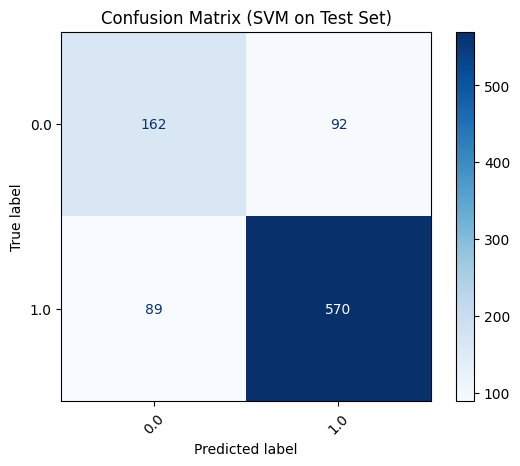

In [32]:
#@title Confusion Matrix
# Predict using the best model from GridSearch
y_pred = grid_search_svm.best_estimator_.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_svm.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (SVM on Test Set)")
plt.grid(False)
plt.show()


In [33]:
# import joblib

# @title  Save the grid search SVM model to a file
# joblib.dump(grid_search_svm, 'grid_search_svm_model.joblib')
# print("SVM Grid Search model saved as 'grid_search_svm_model.joblib'")


### Logistic Regression

In [34]:
#@title Logistic Regression with Default Parameters
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Train Accuracy: 0.8497
Test Accuracy: 0.7930


In [35]:
#@title Logistic Regression with Grid Search
from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l2'],                   # L2 is commonly used
    'solver': ['liblinear', 'lbfgs'],    # liblinear for small data, lbfgs is default
}

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.8196


In [36]:
#@title Classification Report for Logistic Regression
from sklearn.metrics import classification_report

best_logreg = grid_search.best_estimator_

y_train_pred = best_logreg.predict(X_train)
y_test_pred = best_logreg.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.77      0.73      0.75      1154
         1.0       0.88      0.90      0.89      2498

    accuracy                           0.85      3652
   macro avg       0.83      0.82      0.82      3652
weighted avg       0.85      0.85      0.85      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.64      0.63      0.63       254
         1.0       0.86      0.87      0.86       659

    accuracy                           0.80       913
   macro avg       0.75      0.75      0.75       913
weighted avg       0.80      0.80      0.80       913



<Figure size 600x600 with 0 Axes>

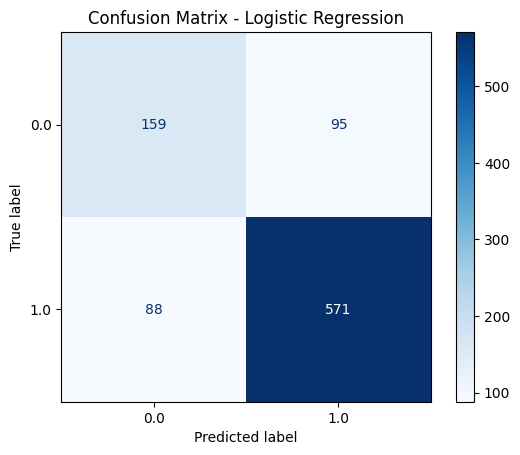

In [37]:
#@title Confusion Matrix for Logistic Regression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test set
y_test_pred = best_logreg.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=best_logreg.classes_)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_logreg.classes_)
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Naive Baise

In [38]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize Gaussian Naive Bayes
gnb = GaussianNB()

# Fit the model
gnb.fit(X_train, y_train)

# Predict on train and test
y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)

# Print accuracies
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


Train Accuracy: 0.6727820372398685
Test Accuracy: 0.6527929901423878


In [39]:
print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.49      0.70      0.58      1154
         1.0       0.83      0.66      0.73      2498

    accuracy                           0.67      3652
   macro avg       0.66      0.68      0.65      3652
weighted avg       0.72      0.67      0.68      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.42      0.69      0.52       254
         1.0       0.84      0.64      0.73       659

    accuracy                           0.65       913
   macro avg       0.63      0.66      0.63       913
weighted avg       0.73      0.65      0.67       913



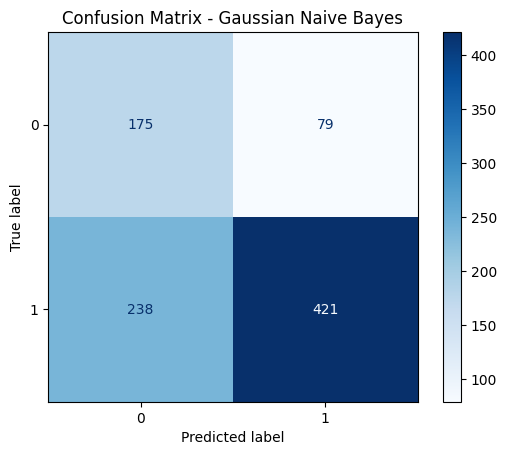

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()


### Neural Network

In [41]:
# pip install --upgrade --force-reinstall numpy tensorflow


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

layers = [
    Dense(units=256, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.3),

    Dense(units=128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.25),

    Dense(units=64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.2),

    Dense(units=32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.15),

    Dense(units=8, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(rate=0.1),

    Dense(units=2, activation='softmax')  # Adjust units if your number of classes differs
]

model = Sequential(layers)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # Use 'categorical_crossentropy' if y_train is one-hot encoded
    metrics=['accuracy']
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

#@title  Fit the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5897 - loss: 5.8533 - val_accuracy: 0.7349 - val_loss: 4.6936
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7103 - loss: 4.4512 - val_accuracy: 0.7579 - val_loss: 3.6137
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7357 - loss: 3.4177 - val_accuracy: 0.7667 - val_loss: 2.7903
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7849 - loss: 2.6580 - val_accuracy: 0.7831 - val_loss: 2.2012
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7853 - loss: 2.1110 - val_accuracy: 0.7831 - val_loss: 1.7704
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8124 - loss: 1.6574 - val_accuracy: 0.7941 - val_loss: 1.4431
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8290 - loss: 1.3406 - val_accuracy: 0.8072 - val_loss: 1.2008
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8387 - loss: 1.1153 - val_accuracy: 0

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



In [ ]:

from sklearn.metrics import classification_report

# Predict on training set
y_train_pred_prob = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred_prob, axis=1)

# Predict on test (validation) set
y_test_pred_prob = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Validation Set")
print(classification_report(y_test, y_test_pred))


In [ ]:
# Predict classes on test set
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.show()


## E3 Try Embedding Only the Named Entities

In [ ]:
#@title Embedding Using Only Named Entities
from sentence_transformers import SentenceTransformer
import numpy as np
import ast

# Initialize once
embedding_model = SentenceTransformer("aubmindlab/bert-base-arabertv2")

def embed_named_entities(named_entities_str, model):
    try:
        named_entities = ast.literal_eval(named_entities_str) if named_entities_str else []
    except (ValueError, SyntaxError):
        named_entities = []

    if not named_entities:
        return np.zeros(model.get_sentence_embedding_dimension())

    vectors = []
    for entity in named_entities:
        emb = model.encode(entity)  # SentenceTransformer method
        vectors.append(emb)

    return np.mean(vectors, axis=0)

df['named_entities_embedding'] = df['Named Entities'].apply(lambda x: embed_named_entities(x, embedding_model))
print(df['named_entities_embedding'].iloc[0].shape)


(768,)


### split the DF

In [ ]:
X = np.vstack(df['named_entities_embedding'].values)
y = df['Label'].values


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### K Nearest Neighbor Classifier

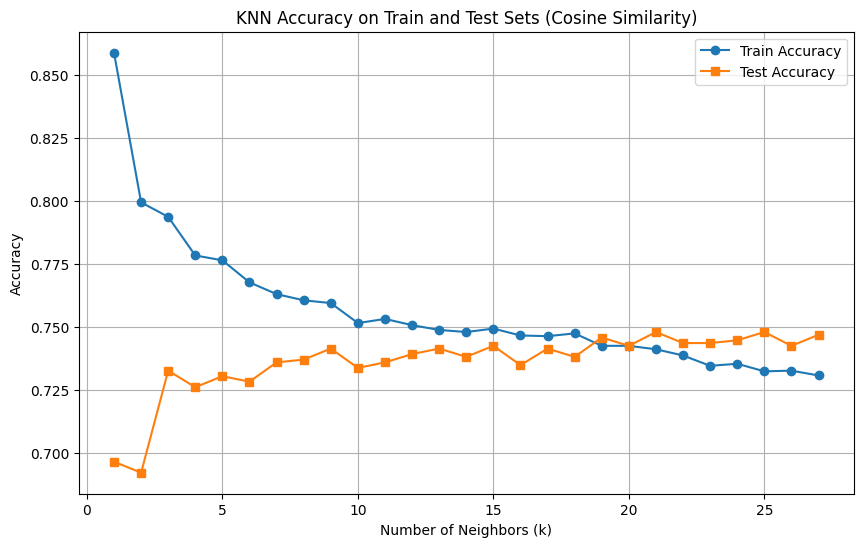

In [ ]:
#@title KNN with K from 1 to root of feature size
# Number of training samples
n_train = X_train.shape[1]

# Maximum k to try: integer part of sqrt(n_train)
max_k = int(sqrt(n_train))

# Store accuracies for train and test
train_accuracies = []
test_accuracies = []

k_values = range(1, max_k + 1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict on train set and test set
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Train and Test Sets (Cosine Similarity)')
plt.legend()
plt.grid(True)
plt.show()


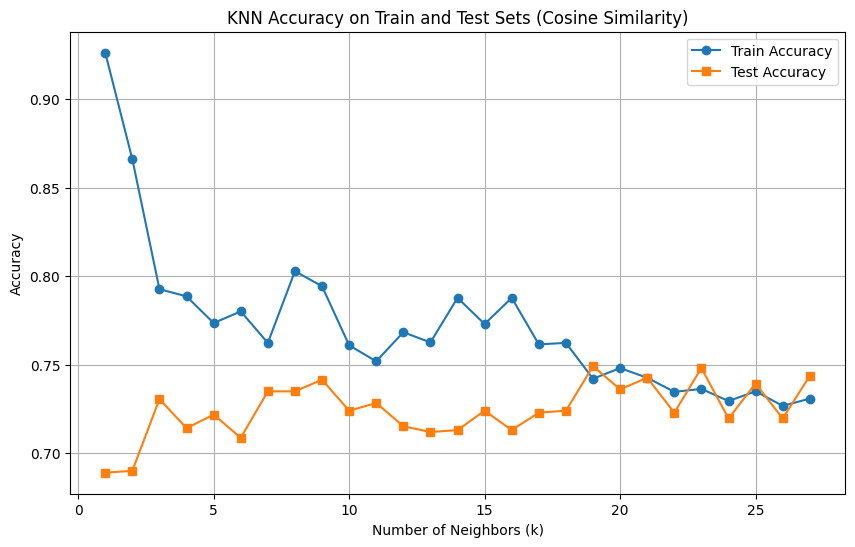

In [ ]:
#@title KNN with Cosine Similarity
# Number of training samples
n_train = X_train.shape[1]

# Maximum k to try: integer part of sqrt(n_train)
max_k = int(sqrt(n_train))

# Store accuracies for train and test
train_accuracies = []
test_accuracies = []

k_values = range(1, max_k + 1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(X_train, y_train)

    # Predict on train set and test set
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Train and Test Sets (Cosine Similarity)')
plt.legend()
plt.grid(True)
plt.show()


Best k based on test accuracy: 19


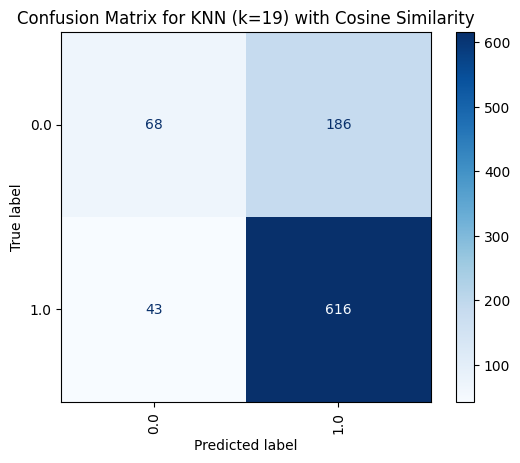

In [ ]:
#@title Confuison Matrix for KNN with Cosine Similarity
# Get the best k based on test accuracy
best_k = k_values[np.argmax(test_accuracies)]
print(f"Best k based on test accuracy: {best_k}")

# Train final model with best_k
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine')
best_knn.fit(X_train, y_train)

# Predict on test set
y_test_pred = best_knn.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y_test))

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title(f'Confusion Matrix for KNN (k={best_k}) with Cosine Similarity')
plt.grid(False)
plt.show()


#### Grid Search for the best Params with f1 Concern

In [ ]:
#@title Define parameter grid
# Calculate max_k based on feature size (embedding length)
embedding_length = X_train.shape[1]
max_k = int(np.sqrt(embedding_length))

# Initialize model
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(7, max_k + 1)),
    'metric': ['cosine', 'euclidean',],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'brute'],
    'leaf_size': [20, 25, 30, 40],
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)


In [ ]:
#@title Fit the Model
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 672 candidates, totalling 3360 fits
Best parameters: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'uniform'}
Best cross-validation accuracy: 0.6392


In [ ]:
#@title Classfication Report
from sklearn.metrics import classification_report

best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.66      0.44      0.53      1154
         1.0       0.77      0.90      0.83      2498

    accuracy                           0.75      3652
   macro avg       0.72      0.67      0.68      3652
weighted avg       0.74      0.75      0.74      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.53      0.34      0.42       254
         1.0       0.78      0.88      0.83       659

    accuracy                           0.73       913
   macro avg       0.66      0.61      0.62       913
weighted avg       0.71      0.73      0.71       913



<Figure size 600x500 with 0 Axes>

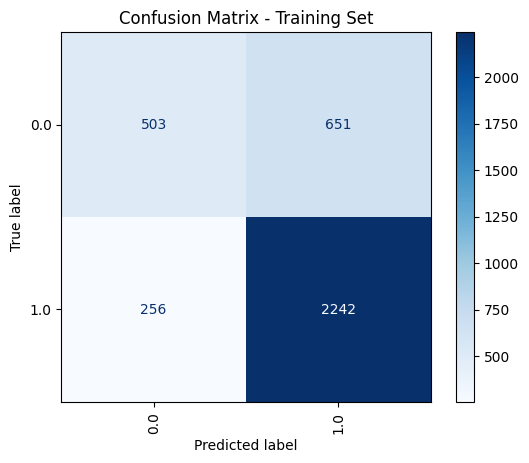

<Figure size 600x500 with 0 Axes>

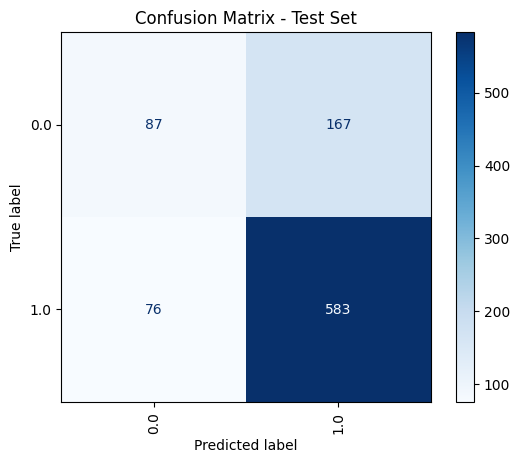

In [ ]:
#@title Confusion Matrix
# Define labels to ensure consistent order in the matrix
labels = np.unique(y_test)

# Confusion Matrix for Training Set
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
plt.figure(figsize=(6,5))
disp_train.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Training Set')
plt.grid(False)
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
plt.figure(figsize=(6,5))
disp_test.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.grid(False)
plt.show()

#### Grid Search for the best Params with recall Concern

In [ ]:
#@title Define parameter grid
# Calculate max_k based on feature size (embedding length)
embedding_length = X_train.shape[1]
max_k = int(np.sqrt(embedding_length))

# Initialize model
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(7, max_k + 1)),
    'metric': ['cosine', 'euclidean',],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'brute'],
    'leaf_size': [20, 25, 30, 40],
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)


In [ ]:
#@title Fit the Model
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 672 candidates, totalling 3360 fits
Best parameters: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'euclidean', 'n_neighbors': 8, 'weights': 'uniform'}
Best cross-validation accuracy: 0.6368


In [ ]:
#@title Classfication Report
from sklearn.metrics import classification_report

best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.68      0.47      0.55      1154
         1.0       0.78      0.90      0.84      2498

    accuracy                           0.76      3652
   macro avg       0.73      0.68      0.69      3652
weighted avg       0.75      0.76      0.75      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.54      0.35      0.43       254
         1.0       0.78      0.89      0.83       659

    accuracy                           0.74       913
   macro avg       0.66      0.62      0.63       913
weighted avg       0.71      0.74      0.72       913



<Figure size 600x500 with 0 Axes>

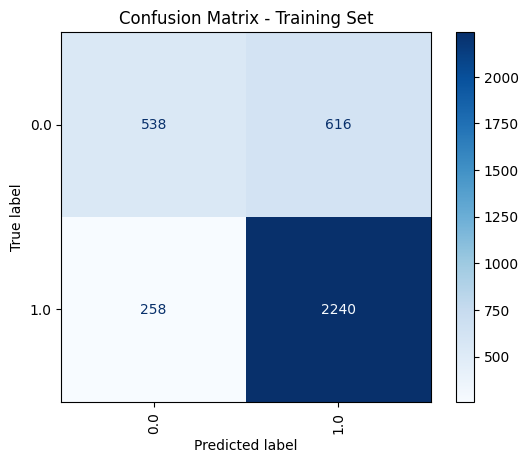

<Figure size 600x500 with 0 Axes>

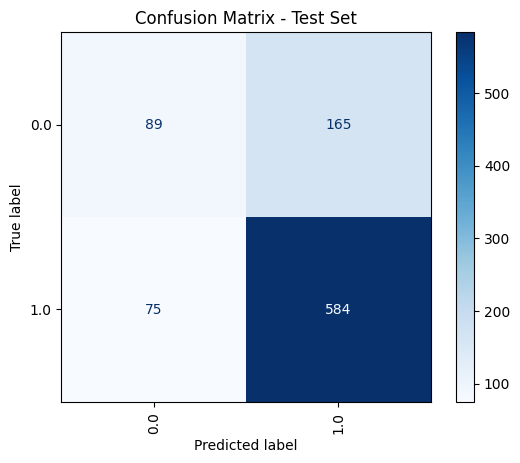

In [ ]:
#@title Confusion Matrix
# Define labels to ensure consistent order in the matrix
labels = np.unique(y_test)

# Confusion Matrix for Training Set
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
plt.figure(figsize=(6,5))
disp_train.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Training Set')
plt.grid(False)
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
plt.figure(figsize=(6,5))
disp_test.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.grid(False)
plt.show()

### SVM

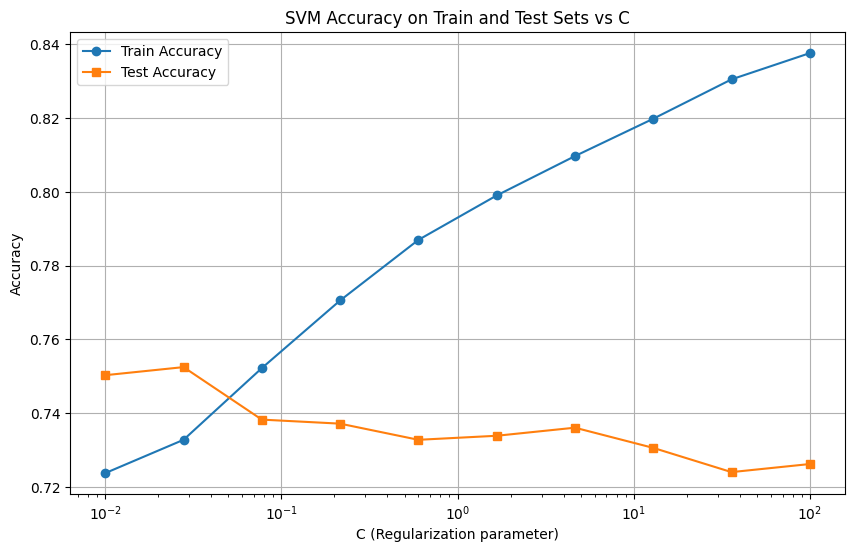

In [ ]:
#@title SVM with Linear kernel (jsut to show a base line )
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Define a range of C values to try (log scale)
C_values = np.logspace(-2, 2, 10)  # 0.01 to 100

train_accuracies = []
test_accuracies = []

for C in C_values:
    svm = SVC(C=C, kernel='linear')  # using linear kernel, you can try others like 'rbf'
    svm.fit(X_train, y_train)

    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(C_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xscale('log')
plt.xlabel('C (Regularization parameter)')
plt.ylabel('Accuracy')
plt.title('SVM Accuracy on Train and Test Sets vs C')
plt.legend()
plt.grid(True)
plt.show()


#### Grid Search  with f1 concern

In [ ]:
#@title Define Parameter Grid
from sklearn.svm import SVC

svm = SVC()

param_grid = {
    'C': [0.01,0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'poly'],  # Kernel types to try'rbf'
    'gamma': ['scale', 'auto']  # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
}

grid_search_svm = GridSearchCV(svm, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)



In [ ]:
#@title Fit the Model
grid_search_svm.fit(X_train, y_train)

print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_svm.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
Best cross-validation accuracy: 0.6509


In [ ]:

#@title Classification Report
best_svm = grid_search_svm.best_estimator_

y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.83      0.55      0.66      1154
         1.0       0.82      0.95      0.88      2498

    accuracy                           0.82      3652
   macro avg       0.83      0.75      0.77      3652
weighted avg       0.82      0.82      0.81      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.55      0.37      0.44       254
         1.0       0.78      0.88      0.83       659

    accuracy                           0.74       913
   macro avg       0.67      0.63      0.64       913
weighted avg       0.72      0.74      0.72       913



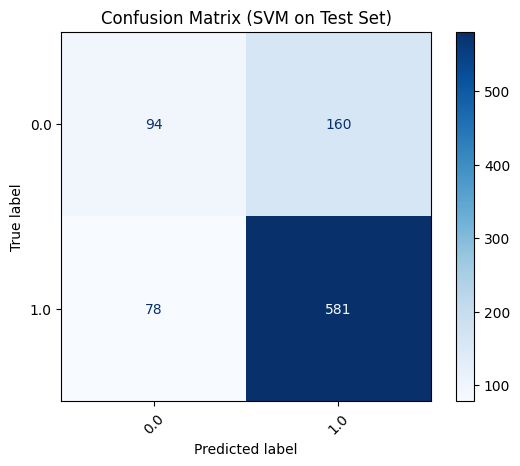

In [ ]:
#@title Confusion Matrix
# Predict using the best model from GridSearch
y_pred = grid_search_svm.best_estimator_.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_svm.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (SVM on Test Set)")
plt.grid(False)
plt.show()


#### Grid Search  with Recall concern

In [ ]:
#@title Define Parameter Grid
from sklearn.svm import SVC

svm = SVC()

param_grid = {
    'C': [0.01,0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'poly'],  # Kernel types to try'rbf'
    'gamma': ['scale', 'auto']  # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
}

grid_search_svm = GridSearchCV(svm, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=2)



In [ ]:
#@title Fit the Model
grid_search_svm.fit(X_train, y_train)

print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_svm.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 0.01, 'gamma': 'scale', 'kernel': 'poly'}
Best cross-validation accuracy: 1.0000


In [ ]:

#@title Classification Report
best_svm = grid_search_svm.best_estimator_

y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1154
         1.0       0.68      1.00      0.81      2498

    accuracy                           0.68      3652
   macro avg       0.34      0.50      0.41      3652
weighted avg       0.47      0.68      0.56      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       254
         1.0       0.72      1.00      0.84       659

    accuracy                           0.72       913
   macro avg       0.36      0.50      0.42       913
weighted avg       0.52      0.72      0.61       913



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

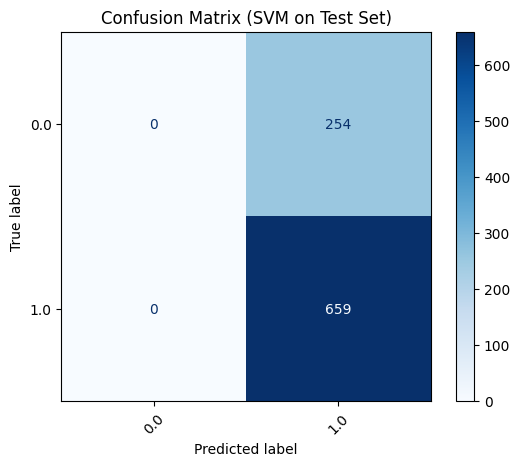

In [ ]:
#@title Confusion Matrix
# Predict using the best model from GridSearch
y_pred = grid_search_svm.best_estimator_.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_svm.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (SVM on Test Set)")
plt.grid(False)
plt.show()


### Logistic Regression

In [ ]:
#@title Logistic Regression with Default Parameters
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Train Accuracy: 0.7796
Test Accuracy: 0.7338


In [ ]:
#@title Logistic Regression with Grid Search
from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l2'],                   # L2 is commonly used
    'solver': ['liblinear', 'lbfgs'],    # liblinear for small data, lbfgs is default
}

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.7295


In [ ]:
#@title Classification Report for Logistic Regression
from sklearn.metrics import classification_report

best_logreg = grid_search.best_estimator_

y_train_pred = best_logreg.predict(X_train)
y_test_pred = best_logreg.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.76      0.44      0.56      1154
         1.0       0.78      0.94      0.85      2498

    accuracy                           0.78      3652
   macro avg       0.77      0.69      0.71      3652
weighted avg       0.78      0.78      0.76      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.54      0.35      0.42       254
         1.0       0.78      0.88      0.83       659

    accuracy                           0.73       913
   macro avg       0.66      0.62      0.63       913
weighted avg       0.71      0.73      0.72       913



<Figure size 600x600 with 0 Axes>

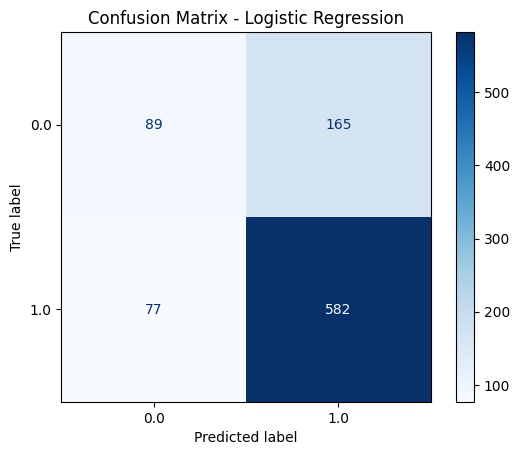

In [ ]:
#@title Confusion Matrix for Logistic Regression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test set
y_test_pred = best_logreg.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=best_logreg.classes_)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_logreg.classes_)
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Naive Baise

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize Gaussian Naive Bayes
gnb = GaussianNB()

# Fit the model
gnb.fit(X_train, y_train)

# Predict on train and test
y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)

# Print accuracies
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


Train Accuracy: 0.6418400876232202
Test Accuracy: 0.6549835706462213


In [ ]:
print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.45      0.58      0.51      1154
         1.0       0.78      0.67      0.72      2498

    accuracy                           0.64      3652
   macro avg       0.61      0.63      0.61      3652
weighted avg       0.67      0.64      0.65      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.41      0.56      0.47       254
         1.0       0.80      0.69      0.74       659

    accuracy                           0.65       913
   macro avg       0.61      0.62      0.61       913
weighted avg       0.69      0.65      0.67       913



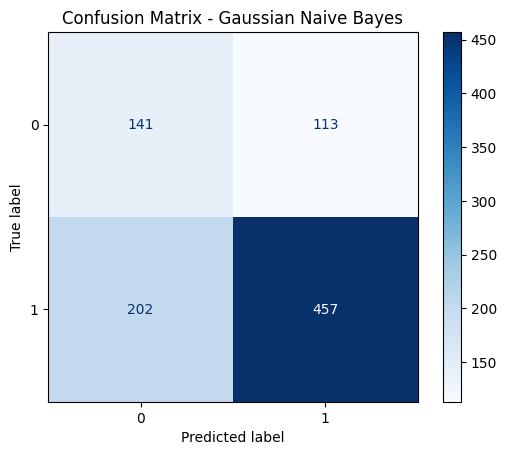

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()


### Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

layers = [
    Dense(units=256, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.3),

    Dense(units=128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.25),

    Dense(units=64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.2),

    Dense(units=32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.15),

    Dense(units=8, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(rate=0.1),

    Dense(units=2, activation='softmax')  # Adjust units if your number of classes differs
]

model = Sequential(layers)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # Use 'categorical_crossentropy' if y_train is one-hot encoded
    metrics=['accuracy']
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

#@title  Fit the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4933 - loss: 7.1595 - val_accuracy: 0.7317 - val_loss: 5.2303
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6531 - loss: 4.8681 - val_accuracy: 0.7229 - val_loss: 3.6786
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6669 - loss: 3.4506 - val_accuracy: 0.7251 - val_loss: 2.6557
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6952 - loss: 2.5238 - val_accuracy: 0.7306 - val_loss: 1.9897
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6874 - loss: 1.9052 - val_accuracy: 0.7262 - val_loss: 1.5725
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6966 - loss: 1.5014 - val_accuracy: 0.7306 - val_loss: 1.2746
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7120 - loss: 1.2361 - val_accuracy: 0.7349 - val_loss: 1.0557
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7146 - loss: 1.0334 - val_accura

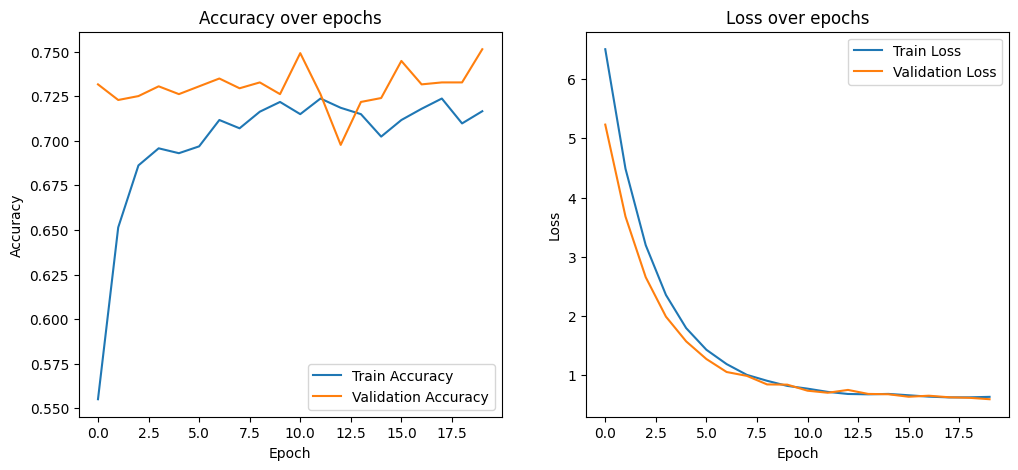

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



In [ ]:

from sklearn.metrics import classification_report

# Predict on training set
y_train_pred_prob = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred_prob, axis=1)

# Predict on test (validation) set
y_test_pred_prob = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Validation Set")
print(classification_report(y_test, y_test_pred))


115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.71      0.25      0.37      1154
         1.0       0.73      0.95      0.83      2498

    accuracy                           0.73      3652
   macro avg       0.72      0.60      0.60      3652
weighted avg       0.73      0.73      0.69      3652

Classification Report - Validation Set
              precision    recall  f1-score   support

         0.0       0.63      0.26      0.36       254
         1.0       0.77      0.94      0.85       659

    accuracy                           0.75       913
   macro avg       0.70      0.60      0.60       913
weighted avg       0.73      0.75      0.71       913



<Figure size 600x600 with 0 Axes>

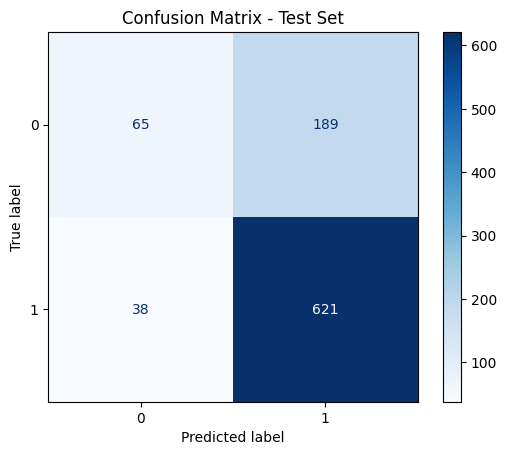

In [ ]:
# Predict classes on test set
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.show()


## E4 Try Placehodlers

In [ ]:
!pip install stanza

In [ ]:
# Install stanza if not installed
# !pip install stanza

import stanza
import numpy as np
import ast
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from math import sqrt

# Step 1: Download and initialize Arabic Stanza pipeline (if you haven't already)
stanza.download('ar')
nlp = stanza.Pipeline(lang='ar', processors='tokenize,ner')

# Step 2: Function to replace LOC, PER, ORG in a tweet text with placeholders
def replace_ner_with_placeholders(text):
    doc = nlp(text)
    replaced_words = []
    for sentence in doc.sentences:
        for word in sentence.words:
            replaced_words.append(word.text)
    # Collect all entities with their spans
    entities = []
    for ent in doc.ents:
        if ent.type == 'LOC':
            replacement = 'مكان'
        elif ent.type == 'PER':
            replacement = 'شخص'
        elif ent.type == 'ORG':
            replacement = 'منظمة'
        else:
            replacement = None

        if replacement:
            entities.append((ent.start_char, ent.end_char, replacement))
    # Replace entities from end to start (to avoid messing up indices)
    replaced_text = text
    for start, end, rep in sorted(entities, key=lambda x: x[0], reverse=True):
        replaced_text = replaced_text[:start] + rep + replaced_text[end:]
    return replaced_text


# Step 4: Embed modified tweets by averaging word vectors
def embed_tweet(text, model):
    words = text.split()
    vectors = []
    for w in words:
        if w in model.key_to_index:
            vectors.append(model[w])
        else:
            vectors.append(np.zeros(model.vector_size))
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: ar (Arabic) ...
INFO:stanza:File exists: /root/stanza_resources/ar/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: ar (Arabic):
| Processor | Package      |
----------------------------
| tokenize  | padt         |
| mwt       | padt         |
| ner       | aqmar_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


In [ ]:
# Step 5: Apply replacement and embedding on your DataFrame column with raw tweets (assuming 'tweet_text' column)
df['tweet_text_replaced'] = df['Tweet Text'].apply(replace_ner_with_placeholders)
df['tweet_embedding'] = df['tweet_text_replaced'].apply(lambda txt: embed_tweet(txt, fasttext_model))


In [ ]:

print("Sample original tweet:", df['Tweet Text'].iloc[10])
print("Sample replaced tweet:", df['tweet_text_replaced'].iloc[10])


Sample original tweet: ماذا سيفعلون في دمشق يتناولون المرطبات مثلا
Sample replaced tweet: ماذا سيفعلون في مكان يتناولون المرطبات مثلا


### split the DF

In [ ]:
X = np.vstack(df['tweet_embedding'].values)
y = df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### K Nearest Neighbor Classifier

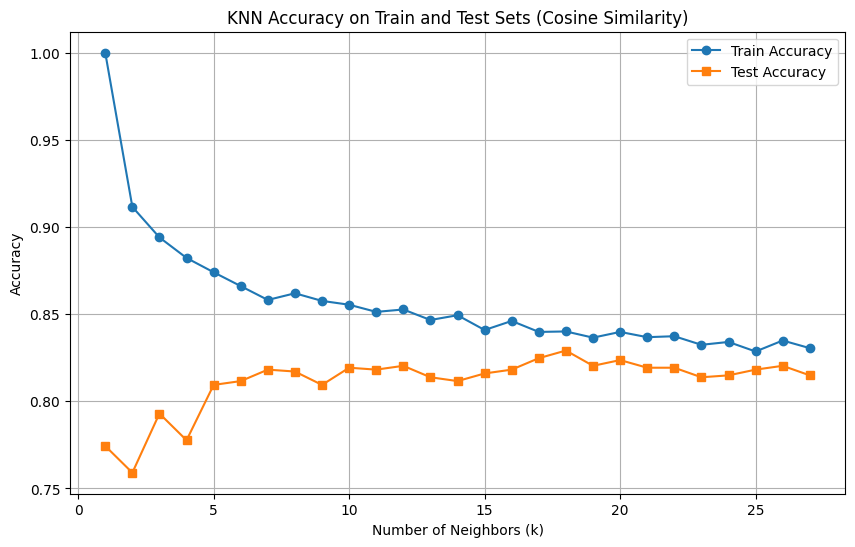

In [ ]:
#@title KNN with K from 1 to root of feature size
# Number of training samples
n_train = X_train.shape[1]

# Maximum k to try: integer part of sqrt(n_train)
max_k = int(sqrt(n_train))

# Store accuracies for train and test
train_accuracies = []
test_accuracies = []

k_values = range(1, max_k + 1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict on train set and test set
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Train and Test Sets (Cosine Similarity)')
plt.legend()
plt.grid(True)
plt.show()


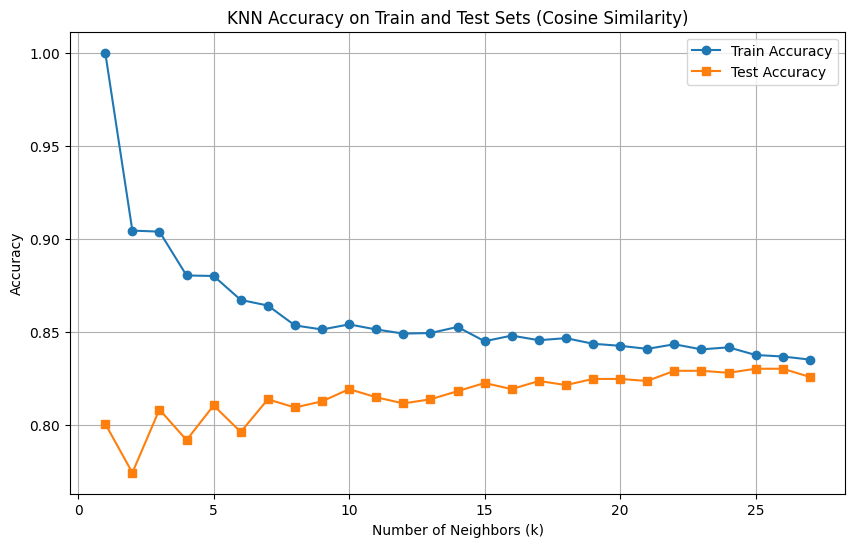

In [ ]:
#@title KNN with Cosine Similarity
# Number of training samples
n_train = X_train.shape[1]

# Maximum k to try: integer part of sqrt(n_train)
max_k = int(sqrt(n_train))

# Store accuracies for train and test
train_accuracies = []
test_accuracies = []

k_values = range(1, max_k + 1)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(X_train, y_train)

    # Predict on train set and test set
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Train and Test Sets (Cosine Similarity)')
plt.legend()
plt.grid(True)
plt.show()


Best k based on test accuracy: 25


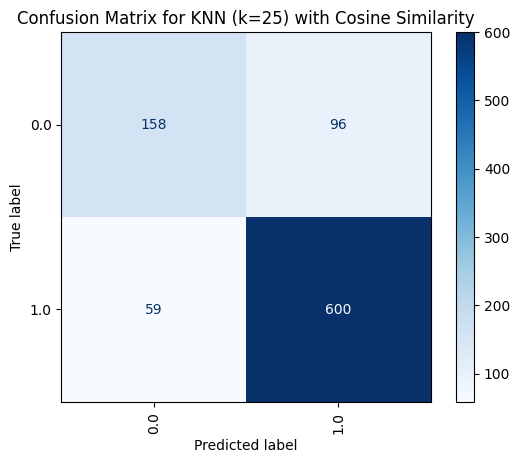

In [ ]:
#@title Confuison Matrix for KNN with Cosine Similarity
# Get the best k based on test accuracy
best_k = k_values[np.argmax(test_accuracies)]
print(f"Best k based on test accuracy: {best_k}")

# Train final model with best_k
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric='cosine')
best_knn.fit(X_train, y_train)

# Predict on test set
y_test_pred = best_knn.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y_test))

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title(f'Confusion Matrix for KNN (k={best_k}) with Cosine Similarity')
plt.grid(False)
plt.show()


#### Grid Search for the best Params with acuracy Concern

In [ ]:
#@title Define parameter grid
# Calculate max_k based on feature size (embedding length)
embedding_length = X_train.shape[1]
max_k = int(np.sqrt(embedding_length))

# Initialize model
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(7, max_k + 1)),
    'metric': ['cosine', 'euclidean',],
    'weights': ['uniform'], #distance
    'algorithm': ['auto', 'brute'],
    'leaf_size': [20, 25, 30, 40],
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)


In [ ]:
#@title Fit the Model
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 336 candidates, totalling 1680 fits
Best parameters: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'cosine', 'n_neighbors': 12, 'weights': 'uniform'}
Best cross-validation accuracy: 0.8256


In [ ]:
#@title Classfication Report
from sklearn.metrics import classification_report

best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.76      0.76      0.76      1154
         1.0       0.89      0.89      0.89      2498

    accuracy                           0.85      3652
   macro avg       0.83      0.83      0.83      3652
weighted avg       0.85      0.85      0.85      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.66      0.68      0.67       254
         1.0       0.88      0.86      0.87       659

    accuracy                           0.81       913
   macro avg       0.77      0.77      0.77       913
weighted avg       0.81      0.81      0.81       913



<Figure size 600x500 with 0 Axes>

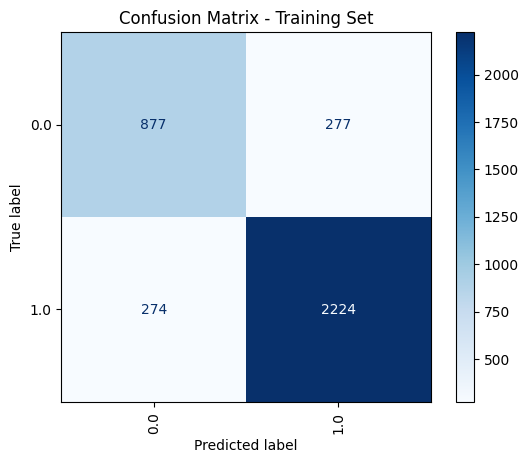

<Figure size 600x500 with 0 Axes>

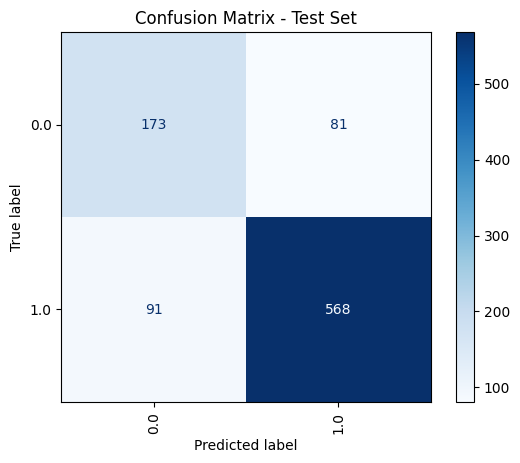

In [ ]:
#@title Confusion Matrix
# Define labels to ensure consistent order in the matrix
labels = np.unique(y_test)

# Confusion Matrix for Training Set
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
plt.figure(figsize=(6,5))
disp_train.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Training Set')
plt.grid(False)
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
plt.figure(figsize=(6,5))
disp_test.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.grid(False)
plt.show()

#### Grid Search for the best Params with recall Concern

In [ ]:
#@title Define parameter grid
# Calculate max_k based on feature size (embedding length)
embedding_length = X_train.shape[1]
max_k = int(np.sqrt(embedding_length))

# Initialize model
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(7, max_k + 1)),
    'metric': ['cosine', 'euclidean',],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'brute'],
    'leaf_size': [20, 25, 30, 40],
}

# Setup Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)


In [ ]:
#@title Fit the Model
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 672 candidates, totalling 3360 fits
Best parameters: {'algorithm': 'auto', 'leaf_size': 20, 'metric': 'cosine', 'n_neighbors': 12, 'weights': 'uniform'}
Best cross-validation accuracy: 0.7967


In [ ]:
#@title Classfication Report
from sklearn.metrics import classification_report

best_knn = grid_search.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_test_pred = best_knn.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.76      0.76      0.76      1154
         1.0       0.89      0.89      0.89      2498

    accuracy                           0.85      3652
   macro avg       0.83      0.83      0.83      3652
weighted avg       0.85      0.85      0.85      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.66      0.68      0.67       254
         1.0       0.88      0.86      0.87       659

    accuracy                           0.81       913
   macro avg       0.77      0.77      0.77       913
weighted avg       0.81      0.81      0.81       913



<Figure size 600x500 with 0 Axes>

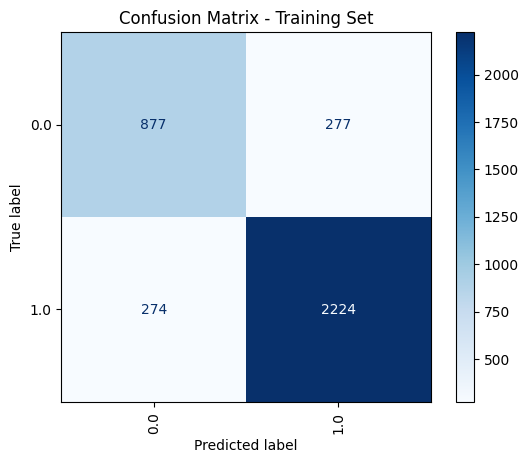

<Figure size 600x500 with 0 Axes>

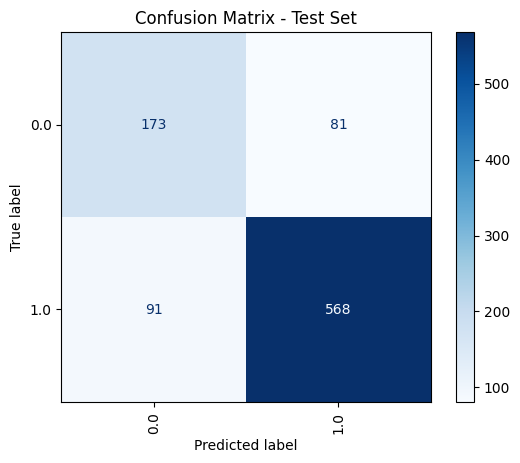

In [ ]:
#@title Confusion Matrix
# Define labels to ensure consistent order in the matrix
labels = np.unique(y_test)

# Confusion Matrix for Training Set
cm_train = confusion_matrix(y_train, y_train_pred, labels=labels)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=labels)
plt.figure(figsize=(6,5))
disp_train.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Training Set')
plt.grid(False)
plt.show()

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_pred, labels=labels)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=labels)
plt.figure(figsize=(6,5))
disp_test.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.grid(False)
plt.show()

### SVM

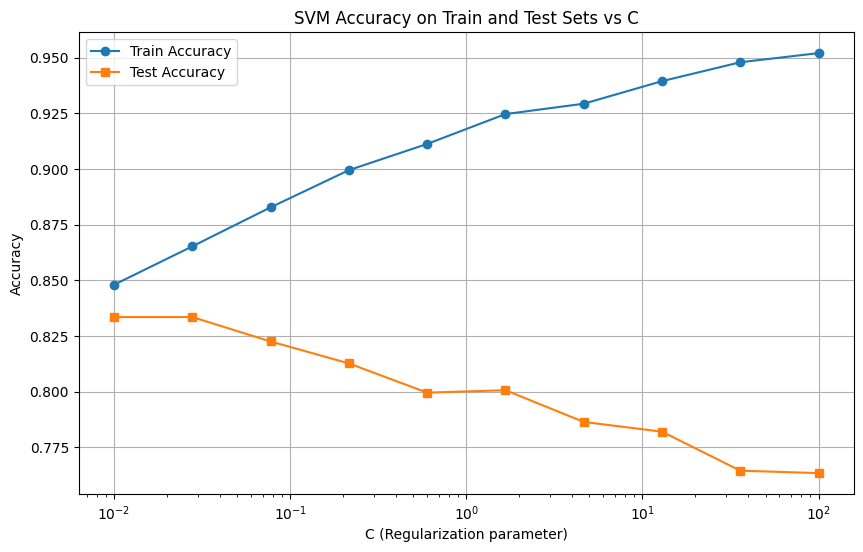

In [ ]:
#@title SVM with Linear kernel (jsut to show a base line )
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Define a range of C values to try (log scale)
C_values = np.logspace(-2, 2, 10)  # 0.01 to 100

train_accuracies = []
test_accuracies = []

for C in C_values:
    svm = SVC(C=C, kernel='linear')  # using linear kernel, you can try others like 'rbf'
    svm.fit(X_train, y_train)

    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(C_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xscale('log')
plt.xlabel('C (Regularization parameter)')
plt.ylabel('Accuracy')
plt.title('SVM Accuracy on Train and Test Sets vs C')
plt.legend()
plt.grid(True)
plt.show()


#### Grid Search  with f1 concern

In [ ]:
#@title Define Parameter Grid
from sklearn.svm import SVC

svm = SVC()

param_grid = {
    'C': [0.001,0.01,0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'poly'],  # Kernel types to try'rbf' 'poly'
    'gamma': ['scale', 'auto'],  # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
    'degree': [2, 3, 4] # Degree for the 'poly' kernel
}

grid_search_svm = GridSearchCV(svm, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=2)

In [ ]:
#@title Fit the Model
grid_search_svm.fit(X_train, y_train)

print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_svm.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.8036


In [ ]:

#@title Classification Report
best_svm = grid_search_svm.best_estimator_

y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.83      0.81      0.82      1154
         1.0       0.91      0.92      0.92      2498

    accuracy                           0.89      3652
   macro avg       0.87      0.87      0.87      3652
weighted avg       0.89      0.89      0.89      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.68      0.67      0.68       254
         1.0       0.87      0.88      0.88       659

    accuracy                           0.82       913
   macro avg       0.78      0.78      0.78       913
weighted avg       0.82      0.82      0.82       913



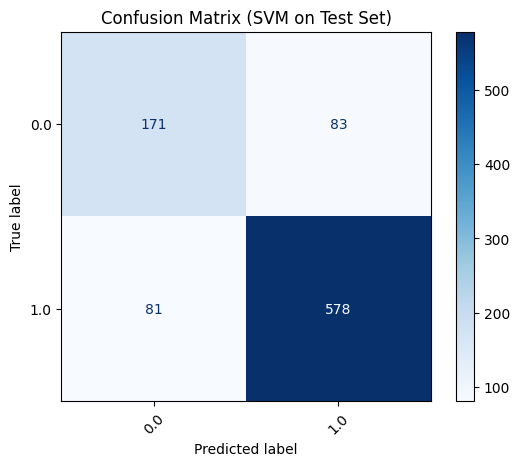

In [ ]:
#@title Confusion Matrix
# Predict using the best model from GridSearch
y_pred = grid_search_svm.best_estimator_.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_svm.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (SVM on Test Set)")
plt.grid(False)
plt.show()


In [ ]:
import joblib

# @title  Save the grid search SVM model to a file
joblib.dump(grid_search_svm, 'grid_search_svm_model.joblib')
print("SVM Grid Search model saved as 'grid_search_svm_model.joblib'")


SVM Grid Search model saved as 'grid_search_svm_model.joblib'


#### Grid Search  with Recall concern

In [ ]:
#@title Define Parameter Grid
from sklearn.svm import SVC

svm = SVC()

param_grid = {
    'C': [0.001,0.01,0.1, 1, 10],  # Regularization parameter
    'kernel': ['linear', 'poly'],  # Kernel types to try'rbf'poly
    'gamma': ['scale', 'auto'],  # Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
    'degree': [2, 3, 4] # Degree for the 'poly' kernel
}

grid_search_svm = GridSearchCV(svm, param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=2)

In [ ]:
#@title Fit the Model
grid_search_svm.fit(X_train, y_train)

print(f"Best parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_svm.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 0.01, 'gamma': 'scale', 'kernel': 'poly'}
Best cross-validation accuracy: 1.0000


In [ ]:

#@title Classification Report
best_svm = grid_search_svm.best_estimator_

y_train_pred = best_svm.predict(X_train)
y_test_pred = best_svm.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.96      0.04      0.07      1154
         1.0       0.69      1.00      0.82      2498

    accuracy                           0.70      3652
   macro avg       0.82      0.52      0.45      3652
weighted avg       0.78      0.70      0.58      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.86      0.02      0.05       254
         1.0       0.73      1.00      0.84       659

    accuracy                           0.73       913
   macro avg       0.79      0.51      0.44       913
weighted avg       0.76      0.73      0.62       913



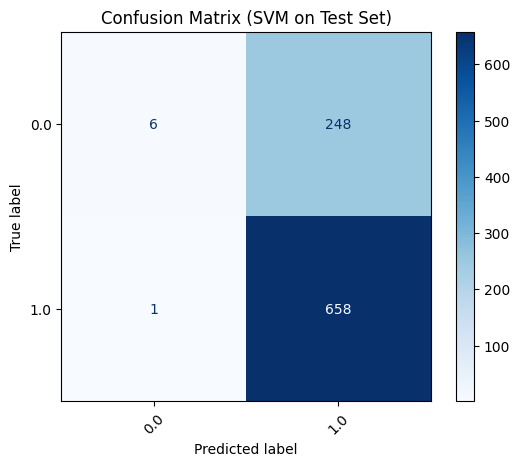

In [ ]:
#@title Confusion Matrix
# Predict using the best model from GridSearch
y_pred = grid_search_svm.best_estimator_.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search_svm.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix (SVM on Test Set)")
plt.grid(False)
plt.show()


In [ ]:
# import joblib

# @title  Save the grid search SVM model to a file
joblib.dump(grid_search_svm, 'grid_search_svm_model.joblib')
print("SVM Grid Search model saved as 'grid_search_svm_model.joblib'")


SVM Grid Search model saved as 'grid_search_svm_model.joblib'


### Logistic Regression

In [ ]:
#@title Logistic Regression with Default Parameters
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Train Accuracy: 0.9055
Test Accuracy: 0.8193


In [ ]:
#@title Logistic Regression with Grid Search
from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l2'],                   # L2 is commonly used
    'solver': ['liblinear', 'lbfgs'],    # liblinear for small data, lbfgs is default
}

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.8343


In [ ]:
#@title Classification Report for Logistic Regression
from sklearn.metrics import classification_report

best_logreg = grid_search.best_estimator_

y_train_pred = best_logreg.predict(X_train)
y_test_pred = best_logreg.predict(X_test)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.81      0.77      0.79      1154
         1.0       0.90      0.92      0.91      2498

    accuracy                           0.87      3652
   macro avg       0.85      0.84      0.85      3652
weighted avg       0.87      0.87      0.87      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.71      0.68      0.69       254
         1.0       0.88      0.89      0.88       659

    accuracy                           0.83       913
   macro avg       0.79      0.79      0.79       913
weighted avg       0.83      0.83      0.83       913



<Figure size 600x600 with 0 Axes>

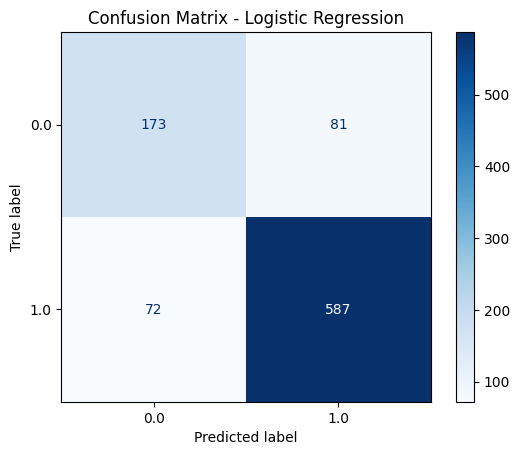

In [ ]:
#@title Confusion Matrix for Logistic Regression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test set
y_test_pred = best_logreg.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=best_logreg.classes_)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_logreg.classes_)
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Naive Baise

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize Gaussian Naive Bayes
gnb = GaussianNB()

# Fit the model
gnb.fit(X_train, y_train)

# Predict on train and test
y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)

# Print accuracies
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


Train Accuracy: 0.7593099671412924
Test Accuracy: 0.7743702081051479


In [ ]:
print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Test Set")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.60      0.70      0.65      1154
         1.0       0.85      0.79      0.82      2498

    accuracy                           0.76      3652
   macro avg       0.73      0.74      0.73      3652
weighted avg       0.77      0.76      0.76      3652

Classification Report - Test Set
              precision    recall  f1-score   support

         0.0       0.58      0.72      0.64       254
         1.0       0.88      0.80      0.84       659

    accuracy                           0.77       913
   macro avg       0.73      0.76      0.74       913
weighted avg       0.80      0.77      0.78       913



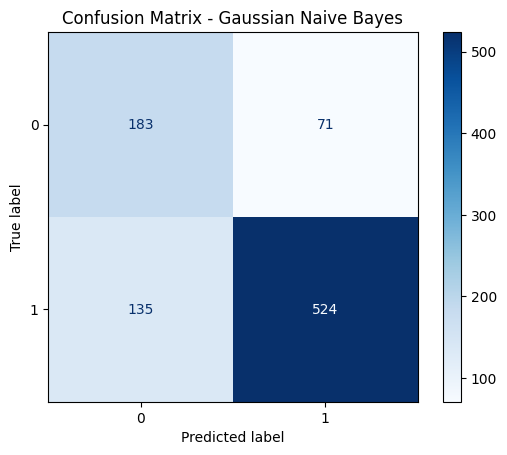

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()


### Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

layers = [
    Dense(units=256, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.3),

    Dense(units=128, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.25),

    Dense(units=64, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.2),

    Dense(units=32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(rate=0.15),

    Dense(units=8, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(rate=0.1),

    Dense(units=2, activation='softmax')  # Adjust units if your number of classes differs
]

model = Sequential(layers)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # Use 'categorical_crossentropy' if y_train is one-hot encoded
    metrics=['accuracy']
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

#@title  Fit the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6915 - loss: 7.0525 - val_accuracy: 0.7360 - val_loss: 5.2878
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7642 - loss: 4.8076 - val_accuracy: 0.7645 - val_loss: 3.5512
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7915 - loss: 3.2929 - val_accuracy: 0.8313 - val_loss: 2.4897
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8057 - loss: 2.2818 - val_accuracy: 0.8160 - val_loss: 1.7618
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8193 - loss: 1.6339 - val_accuracy: 0.7985 - val_loss: 1.3340
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8032 - loss: 1.2471 - val_accuracy: 0.8313 - val_loss: 1.0214
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8362 - loss: 0.9452 - val_accuracy: 0.8105 - val_loss: 0.8401
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8236 - loss: 0.7902 - val_accuracy

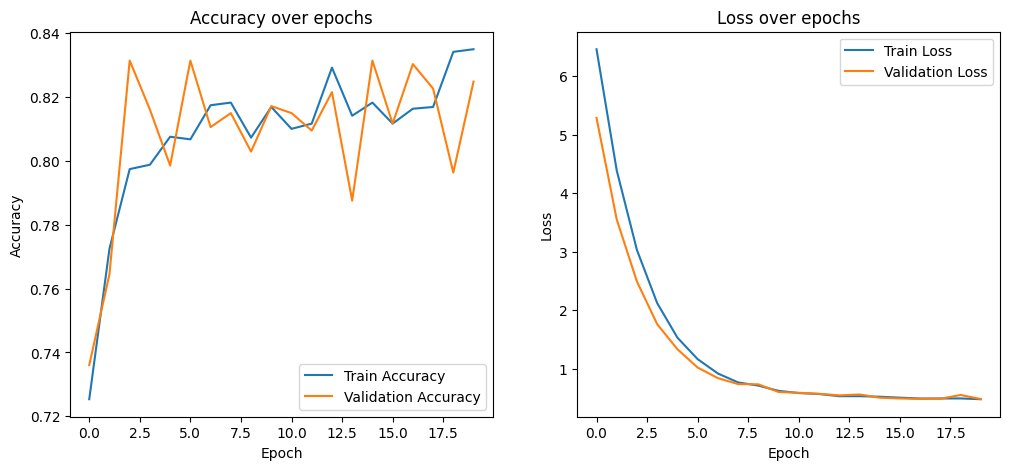

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np


# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



In [ ]:

from sklearn.metrics import classification_report

# Predict on training set
y_train_pred_prob = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred_prob, axis=1)

# Predict on test (validation) set
y_test_pred_prob = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

print("Classification Report - Training Set")
print(classification_report(y_train, y_train_pred))

print("Classification Report - Validation Set")
print(classification_report(y_test, y_test_pred))


115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report - Training Set
              precision    recall  f1-score   support

         0.0       0.80      0.78      0.79      1154
         1.0       0.90      0.91      0.91      2498

    accuracy                           0.87      3652
   macro avg       0.85      0.85      0.85      3652
weighted avg       0.87      0.87      0.87      3652

Classification Report - Validation Set
              precision    recall  f1-score   support

         0.0       0.68      0.69      0.69       254
         1.0       0.88      0.88      0.88       659

    accuracy                           0.82       913
   macro avg       0.78      0.78      0.78       913
weighted avg       0.83      0.82      0.82       913



<Figure size 600x600 with 0 Axes>

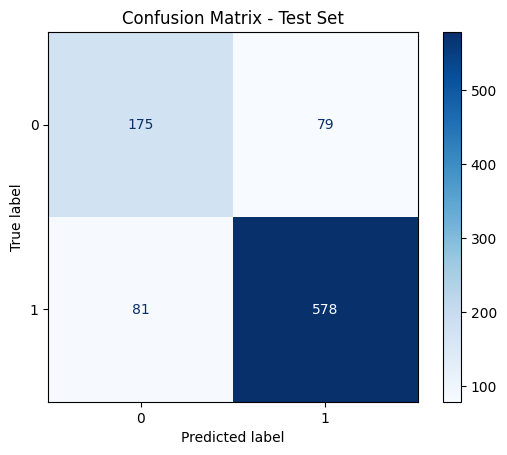

In [ ]:
# Predict classes on test set
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set')
plt.show()


## Conclusion

In [ ]:
# @title Saving The Data Set
df.to_csv("drive/MyDrive/labeled.csv")

In [ ]:
from sklearn.decomposition import PCA

# Assuming X_train and X_test contain the mBERT embeddings
pca = PCA(n_components=200)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"Reduced X_train shape: {X_train_reduced.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Reduced X_test shape: {X_test_reduced.shape}")